In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut

In [2]:
# Set the style for plots
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv('railway.csv')

In [4]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,12/8/2023,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,1/1/2024,11:00:00,13:30:00,13:30:00,On Time,NaN,No
1,b0cdd1b0-f214-4197-be53,12/16/2023,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,1/1/2024,9:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,12/19/2023,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,1/2/2024,18:15:00,18:45:00,18:45:00,On Time,NaN,No
3,b2471f11-4fe7-4c87-8ab4,12/20/2023,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,1/1/2024,21:30:00,22:30:00,22:30:00,On Time,NaN,No
4,2be00b45-0762-485e-a7a3,12/27/2023,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,1/1/2024,16:45:00,19:00:00,19:00:00,On Time,NaN,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Transaction ID       31653 non-null  object
 1   Date of Purchase     31653 non-null  object
 2   Time of Purchase     31653 non-null  object
 3   Purchase Type        31653 non-null  object
 4   Payment Method       31653 non-null  object
 5   Railcard             10735 non-null  object
 6   Ticket Class         31653 non-null  object
 7   Ticket Type          31653 non-null  object
 8   Price                31653 non-null  int64 
 9   Departure Station    31653 non-null  object
 10  Arrival Destination  31653 non-null  object
 11  Date of Journey      31653 non-null  object
 12  Departure Time       31653 non-null  object
 13  Arrival Time         31653 non-null  object
 14  Actual Arrival Time  29773 non-null  object
 15  Journey Status       31653 non-null  object
 16  Reas

In [6]:
df.isnull().sum()

Transaction ID             0
Date of Purchase           0
Time of Purchase           0
Purchase Type              0
Payment Method             0
Railcard               20918
Ticket Class               0
Ticket Type                0
Price                      0
Departure Station          0
Arrival Destination        0
Date of Journey            0
Departure Time             0
Arrival Time               0
Actual Arrival Time     1880
Journey Status             0
Reason for Delay       27481
Refund Request             0
dtype: int64

In [7]:
df.describe(include='all')

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
count,31653,31653,31653,31653,31653,10735,31653,31653,31653.000000,31653,31653,31653,31653,31653,29773,31653,4172,31653
unique,31653,128,24351,2,3,3,2,3,NaN,12,32,121,96,203,623,3,8,2
top,da8a6ba8-b3dc-4677-b176,2/2/2024,8:16:53,Online,Credit Card,Adult,Standard,Advance,NaN,Manchester Piccadilly,Birmingham New Street,3/9/2024,18:45:00,19:05:00,19:05:00,On Time,Weather,No
freq,1,513,6,18521,19136,4846,28595,17561,NaN,5650,7742,313,2598,1069,1013,27481,995,30535
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.439200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.997628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
categorical_columns = ['Purchase Type', 'Payment Method', 'Railcard', 'Ticket Class', 'Ticket Type', 'Journey Status','Reason for Delay']
for col in categorical_columns:
    print(f"Unique values in {col}: {df[col].unique()}")

Unique values in Purchase Type: ['Online' 'Station']
Unique values in Payment Method: ['Contactless' 'Credit Card' 'Debit Card']
Unique values in Railcard: ['Adult' nan 'Disabled' 'Senior']
Unique values in Ticket Class: ['Standard' 'First Class']
Unique values in Ticket Type: ['Advance' 'Off-Peak' 'Anytime']
Unique values in Journey Status: ['On Time' 'Delayed' 'Cancelled']
Unique values in Reason for Delay: [nan 'Signal Failure' 'Technical Issue' 'Weather Conditions' 'Weather'
 'Staffing' 'Staff Shortage' 'Signal failure' 'Traffic']


In [9]:
replacement_mapping = {
    'Signal failure': 'Signal Failure',
    'Weather': 'Weather Conditions',
    'Staffing': 'Staff Shortage'
}

df['Reason for Delay'] = df['Reason for Delay'].replace(replacement_mapping)

In [10]:
categorical_columns = ['Purchase Type', 'Payment Method', 'Railcard', 'Ticket Class', 'Ticket Type', 'Journey Status','Reason for Delay']
for col in categorical_columns:
    print(f"Unique values in {col}: {df[col].unique()}")

Unique values in Purchase Type: ['Online' 'Station']
Unique values in Payment Method: ['Contactless' 'Credit Card' 'Debit Card']
Unique values in Railcard: ['Adult' nan 'Disabled' 'Senior']
Unique values in Ticket Class: ['Standard' 'First Class']
Unique values in Ticket Type: ['Advance' 'Off-Peak' 'Anytime']
Unique values in Journey Status: ['On Time' 'Delayed' 'Cancelled']
Unique values in Reason for Delay: [nan 'Signal Failure' 'Technical Issue' 'Weather Conditions'
 'Staff Shortage' 'Traffic']


In [11]:
df['Railcard'].fillna('No card', inplace=True)

C:\Users\dramo\AppData\Local\Temp\ipykernel_2492\1912679707.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Railcard'].fillna('No card', inplace=True)


In [12]:
categorical_columns = ['Purchase Type', 'Payment Method', 'Railcard', 'Ticket Class', 'Ticket Type', 'Journey Status']
for col in categorical_columns:
    print(f"Unique values in {col}: {df[col].unique()}")

Unique values in Purchase Type: ['Online' 'Station']
Unique values in Payment Method: ['Contactless' 'Credit Card' 'Debit Card']
Unique values in Railcard: ['Adult' 'No card' 'Disabled' 'Senior']
Unique values in Ticket Class: ['Standard' 'First Class']
Unique values in Ticket Type: ['Advance' 'Off-Peak' 'Anytime']
Unique values in Journey Status: ['On Time' 'Delayed' 'Cancelled']


In [13]:
df['Reason for Delay'].fillna('No delay', inplace=True)

C:\Users\dramo\AppData\Local\Temp\ipykernel_2492\1172746670.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Reason for Delay'].fillna('No delay', inplace=True)


In [14]:
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'], dayfirst=False)

In [15]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,1/1/2024,11:00:00,13:30:00,13:30:00,On Time,No delay,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,1/1/2024,9:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,No card,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,1/2/2024,18:15:00,18:45:00,18:45:00,On Time,No delay,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,No card,Standard,Advance,13,London Paddington,Reading,1/1/2024,21:30:00,22:30:00,22:30:00,On Time,No delay,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,No card,Standard,Advance,76,Liverpool Lime Street,London Euston,1/1/2024,16:45:00,19:00:00,19:00:00,On Time,No delay,No


In [16]:
df['Time of Purchase'] = pd.to_datetime(df['Time of Purchase']).dt.time

C:\Users\dramo\AppData\Local\Temp\ipykernel_2492\364107333.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time of Purchase'] = pd.to_datetime(df['Time of Purchase']).dt.time


In [17]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,1/1/2024,11:00:00,13:30:00,13:30:00,On Time,No delay,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,1/1/2024,9:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,No card,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,1/2/2024,18:15:00,18:45:00,18:45:00,On Time,No delay,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,No card,Standard,Advance,13,London Paddington,Reading,1/1/2024,21:30:00,22:30:00,22:30:00,On Time,No delay,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,No card,Standard,Advance,76,Liverpool Lime Street,London Euston,1/1/2024,16:45:00,19:00:00,19:00:00,On Time,No delay,No


In [18]:
# checking if any trip that's not cancelled has no actual arrival time
null_actual_arrival = df[df['Actual Arrival Time'].isnull()]
journey_status_for_nulls = null_actual_arrival['Journey Status'].unique()
print(journey_status_for_nulls)

['Cancelled']


In [19]:
df['Route'] = df['Departure Station'] + ' to ' + df['Arrival Destination']

In [20]:
print(df[['Departure Station', 'Arrival Destination', 'Route']].head())

       Departure Station    Arrival Destination  \
0      London Paddington  Liverpool Lime Street   
1     London Kings Cross                   York   
2  Liverpool Lime Street  Manchester Piccadilly   
3      London Paddington                Reading   
4  Liverpool Lime Street          London Euston   

                                            Route  
0      London Paddington to Liverpool Lime Street  
1                      London Kings Cross to York  
2  Liverpool Lime Street to Manchester Piccadilly  
3                    London Paddington to Reading  
4          Liverpool Lime Street to London Euston  


In [21]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request,Route
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,1/1/2024,11:00:00,13:30:00,13:30:00,On Time,No delay,No,London Paddington to Liverpool Lime Street
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,1/1/2024,9:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No,London Kings Cross to York
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,No card,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,1/2/2024,18:15:00,18:45:00,18:45:00,On Time,No delay,No,Liverpool Lime Street to Manchester Piccadilly
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,No card,Standard,Advance,13,London Paddington,Reading,1/1/2024,21:30:00,22:30:00,22:30:00,On Time,No delay,No,London Paddington to Reading
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,No card,Standard,Advance,76,Liverpool Lime Street,London Euston,1/1/2024,16:45:00,19:00:00,19:00:00,On Time,No delay,No,Liverpool Lime Street to London Euston


In [22]:
df['Arrival DateTime'] = pd.to_datetime(df['Date of Journey'] + ' ' + df['Arrival Time'], dayfirst=False)
df['Actual Arrival DateTime'] = pd.to_datetime(df['Date of Journey'] + ' ' + df['Actual Arrival Time'], dayfirst=False)

In [23]:
# Calculate the delay in minutes
df['Delay in Minutes'] = (df['Actual Arrival DateTime'] - df['Arrival DateTime']).dt.total_seconds() / 60

In [24]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,...,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request,Route,Arrival DateTime,Actual Arrival DateTime,Delay in Minutes
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,...,11:00:00,13:30:00,13:30:00,On Time,No delay,No,London Paddington to Liverpool Lime Street,2024-01-01 13:30:00,2024-01-01 13:30:00,0.0
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,...,9:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No,London Kings Cross to York,2024-01-01 11:35:00,2024-01-01 11:40:00,5.0
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,No card,Standard,Advance,3,Liverpool Lime Street,...,18:15:00,18:45:00,18:45:00,On Time,No delay,No,Liverpool Lime Street to Manchester Piccadilly,2024-01-02 18:45:00,2024-01-02 18:45:00,0.0
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,No card,Standard,Advance,13,London Paddington,...,21:30:00,22:30:00,22:30:00,On Time,No delay,No,London Paddington to Reading,2024-01-01 22:30:00,2024-01-01 22:30:00,0.0
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,No card,Standard,Advance,76,Liverpool Lime Street,...,16:45:00,19:00:00,19:00:00,On Time,No delay,No,Liverpool Lime Street to London Euston,2024-01-01 19:00:00,2024-01-01 19:00:00,0.0


In [25]:
# Check for duplicates based on 'Route', 'Date of Journey', and 'Departure Time'
duplicates = df.duplicated(subset=['Route', 'Date of Journey', 'Departure Time'], keep=False)

# Filter the DataFrame to show only duplicate rows
duplicate_rows = df[duplicates]

# Display the duplicate rows
print("Duplicate Rows:")
len(duplicate_rows)

Duplicate Rows:


17949

In [26]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,...,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request,Route,Arrival DateTime,Actual Arrival DateTime,Delay in Minutes
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,...,11:00:00,13:30:00,13:30:00,On Time,No delay,No,London Paddington to Liverpool Lime Street,2024-01-01 13:30:00,2024-01-01 13:30:00,0.0
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,...,9:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No,London Kings Cross to York,2024-01-01 11:35:00,2024-01-01 11:40:00,5.0
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,No card,Standard,Advance,3,Liverpool Lime Street,...,18:15:00,18:45:00,18:45:00,On Time,No delay,No,Liverpool Lime Street to Manchester Piccadilly,2024-01-02 18:45:00,2024-01-02 18:45:00,0.0
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,No card,Standard,Advance,13,London Paddington,...,21:30:00,22:30:00,22:30:00,On Time,No delay,No,London Paddington to Reading,2024-01-01 22:30:00,2024-01-01 22:30:00,0.0
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,No card,Standard,Advance,76,Liverpool Lime Street,...,16:45:00,19:00:00,19:00:00,On Time,No delay,No,Liverpool Lime Street to London Euston,2024-01-01 19:00:00,2024-01-01 19:00:00,0.0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Transaction ID           31653 non-null  object        
 1   Date of Purchase         31653 non-null  datetime64[ns]
 2   Time of Purchase         31653 non-null  object        
 3   Purchase Type            31653 non-null  object        
 4   Payment Method           31653 non-null  object        
 5   Railcard                 31653 non-null  object        
 6   Ticket Class             31653 non-null  object        
 7   Ticket Type              31653 non-null  object        
 8   Price                    31653 non-null  int64         
 9   Departure Station        31653 non-null  object        
 10  Arrival Destination      31653 non-null  object        
 11  Date of Journey          31653 non-null  object        
 12  Departure Time           31653 n

In [28]:
# Group by ['Route', 'Date of Journey', 'Departure Time'] and check for unique 'Journey Status' values
grouped = df.groupby(['Route', 'Date of Journey', 'Departure Time'])['Journey Status'].nunique()

# Filter groups where the number of unique 'Journey Status' values is greater than 1
conflicting_groups = grouped[grouped > 1]

# Display the conflicting groups
print("Conflicting Groups (Same Route, Date, Departure Time but Different Journey Status):")
print(conflicting_groups)

Conflicting Groups (Same Route, Date, Departure Time but Different Journey Status):
Series([], Name: Journey Status, dtype: int64)


In [29]:
trips = df[['Route', 'Date of Journey', 'Departure Time', 'Departure Station', 'Arrival Destination', 'Arrival Time', 'Actual Arrival Time', 'Journey Status', 'Reason for Delay', 'Delay in Minutes']].drop_duplicates()

In [30]:
trips.head()

,Route,Date of Journey,Departure Time,Departure Station,Arrival Destination,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Delay in Minutes
0,London Paddington to Liverpool Lime Street,1/1/2024,11:00:00,London Paddington,Liverpool Lime Street,13:30:00,13:30:00,On Time,No delay,0.0
1,London Kings Cross to York,1/1/2024,9:45:00,London Kings Cross,York,11:35:00,11:40:00,Delayed,Signal Failure,5.0
2,Liverpool Lime Street to Manchester Piccadilly,1/2/2024,18:15:00,Liverpool Lime Street,Manchester Piccadilly,18:45:00,18:45:00,On Time,No delay,0.0
3,London Paddington to Reading,1/1/2024,21:30:00,London Paddington,Reading,22:30:00,22:30:00,On Time,No delay,0.0
4,Liverpool Lime Street to London Euston,1/1/2024,16:45:00,Liverpool Lime Street,London Euston,19:00:00,19:00:00,On Time,No delay,0.0


In [31]:
trips['Trip ID'] = range(1, len(trips) + 1)

In [32]:
trips.head()

,Route,Date of Journey,Departure Time,Departure Station,Arrival Destination,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Delay in Minutes,Trip ID
0,London Paddington to Liverpool Lime Street,1/1/2024,11:00:00,London Paddington,Liverpool Lime Street,13:30:00,13:30:00,On Time,No delay,0.0,1
1,London Kings Cross to York,1/1/2024,9:45:00,London Kings Cross,York,11:35:00,11:40:00,Delayed,Signal Failure,5.0,2
2,Liverpool Lime Street to Manchester Piccadilly,1/2/2024,18:15:00,Liverpool Lime Street,Manchester Piccadilly,18:45:00,18:45:00,On Time,No delay,0.0,3
3,London Paddington to Reading,1/1/2024,21:30:00,London Paddington,Reading,22:30:00,22:30:00,On Time,No delay,0.0,4
4,Liverpool Lime Street to London Euston,1/1/2024,16:45:00,Liverpool Lime Street,London Euston,19:00:00,19:00:00,On Time,No delay,0.0,5


In [35]:
# Merge the 'Trip ID' from 'trips' into the original DataFrame 'df'
df = df.merge(trips[['Route', 'Date of Journey', 'Departure Time', 'Trip ID']], 
              on=['Route', 'Date of Journey', 'Departure Time'], 
              how='left')

# Display the updated 'df' DataFrame
print("Updated Original DataFrame with Trip ID:")
print(df[['Route', 'Date of Journey', 'Departure Time', 'Trip ID']].head())

Updated Original DataFrame with Trip ID:
                                            Route Date of Journey  \
0      London Paddington to Liverpool Lime Street        1/1/2024   
1                      London Kings Cross to York        1/1/2024   
2  Liverpool Lime Street to Manchester Piccadilly        1/2/2024   
3                    London Paddington to Reading        1/1/2024   
4          Liverpool Lime Street to London Euston        1/1/2024   

  Departure Time  Trip ID  
0       11:00:00        1  
1        9:45:00        2  
2       18:15:00        3  
3       21:30:00        4  
4       16:45:00        5  


In [40]:
unique_departures = df['Departure Station'].unique()
unique_arrivals = df['Arrival Destination'].unique()

In [50]:
stations = pd.unique(np.concatenate([unique_departures, unique_arrivals]))

In [51]:
# stations = pd.unique(np.concatenate([unique_departures, unique_arrivals]))

In [52]:
stations

array(['London Paddington', 'London Kings Cross', 'Liverpool Lime Street',
       'London Euston', 'York', 'Manchester Piccadilly',
       'Birmingham New Street', 'London St Pancras', 'Oxford', 'Reading',
       'Edinburgh Waverley', 'Bristol Temple Meads', 'Durham', 'Tamworth',
       'London Waterloo', 'Sheffield', 'Wolverhampton', 'Leeds',
       'Stafford', 'Doncaster', 'Swindon', 'Nottingham', 'Peterborough',
       'Edinburgh', 'Crewe', 'Leicester', 'Nuneaton', 'Didcot',
       'Coventry', 'Wakefield', 'Cardiff Central', 'Warrington'],
      dtype=object)

In [71]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,...,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request,Route,Arrival DateTime,Actual Arrival DateTime,Delay in Minutes,Trip ID
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,...,13:30:00,13:30:00,On Time,No delay,No,London Paddington to Liverpool Lime Street,2024-01-01 13:30:00,2024-01-01 13:30:00,0.0,1
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,...,11:35:00,11:40:00,Delayed,Signal Failure,No,London Kings Cross to York,2024-01-01 11:35:00,2024-01-01 11:40:00,5.0,2
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,No card,Standard,Advance,3,Liverpool Lime Street,...,18:45:00,18:45:00,On Time,No delay,No,Liverpool Lime Street to Manchester Piccadilly,2024-01-02 18:45:00,2024-01-02 18:45:00,0.0,3
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,No card,Standard,Advance,13,London Paddington,...,22:30:00,22:30:00,On Time,No delay,No,London Paddington to Reading,2024-01-01 22:30:00,2024-01-01 22:30:00,0.0,4
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,No card,Standard,Advance,76,Liverpool Lime Street,...,19:00:00,19:00:00,On Time,No delay,No,Liverpool Lime Street to London Euston,2024-01-01 19:00:00,2024-01-01 19:00:00,0.0,5


In [77]:
pip install geopy

Note: you may need to restart the kernel to use updated packages.


In [78]:
# Initialize the geolocator
geolocator = Nominatim(user_agent="station_geocoder")

# Function to get coordinates
def get_coordinates(station):
    try:
        location = geolocator.geocode(f"{station}, UK")
        if location:
            return location.latitude, location.longitude
        else:
            return None, None
    except GeocoderTimedOut:
        return None, None

# Array of station names
stations = [
    'London Paddington', 'London Kings Cross', 'Liverpool Lime Street',
    'London Euston', 'York', 'Manchester Piccadilly',
    'Birmingham New Street', 'London St Pancras', 'Oxford', 'Reading',
    'Edinburgh Waverley', 'Bristol Temple Meads', 'Durham', 'Tamworth',
    'London Waterloo', 'Sheffield', 'Wolverhampton', 'Leeds',
    'Stafford', 'Doncaster', 'Swindon', 'Nottingham', 'Peterborough',
    'Edinburgh', 'Crewe', 'Leicester', 'Nuneaton', 'Didcot',
    'Coventry', 'Wakefield', 'Cardiff Central', 'Warrington'
]

# Fetch coordinates for each station
station_data = []
for station in stations:
    lat, lon = get_coordinates(station)
    station_data.append({'Station': station, 'Latitude': lat, 'Longitude': lon})

# Create a DataFrame
df_stations = pd.DataFrame(station_data)

# Display the DataFrame
print(df_stations)

                  Station   Latitude  Longitude
0       London Paddington  51.517095  -0.177317
1      London Kings Cross  51.532395  -0.123022
2   Liverpool Lime Street  53.407609  -2.977585
3           London Euston  51.528853  -0.134191
4                    York  53.965658  -1.074305
5   Manchester Piccadilly  53.477420  -2.230833
6   Birmingham New Street  52.477646  -1.898694
7       London St Pancras  51.532361  -0.127226
8                  Oxford  51.752013  -1.257850
9                 Reading  51.451495  -0.983634
10     Edinburgh Waverley  55.951902  -3.190420
11   Bristol Temple Meads  51.449099  -2.580403
12                 Durham  54.666667  -1.750000
13               Tamworth  52.634582  -1.694844
14        London Waterloo  51.502838  -0.112801
15              Sheffield  53.380663  -1.470228
16          Wolverhampton  52.584765  -2.127567
17                  Leeds  53.797418  -1.543794
18               Stafford  52.806316  -2.116382
19              Doncaster  53.522768  -1

In [79]:
df_stations.head()

,Station,Latitude,Longitude
0,London Paddington,51.517095,-0.177317
1,London Kings Cross,51.532395,-0.123022
2,Liverpool Lime Street,53.407609,-2.977585
3,London Euston,51.528853,-0.134191
4,York,53.965658,-1.074305


In [80]:
# Define the station name to ID mapping
station_id_mapping = {
    'London Paddington': 'PAD',
    'London Kings Cross': 'KGX',
    'Liverpool Lime Street': 'LIV',
    'London Euston': 'EUS',
    'York': 'YRK',
    'Manchester Piccadilly': 'MAN',
    'Birmingham New Street': 'BHM',
    'London St Pancras': 'STP',
    'Oxford': 'OXF',
    'Reading': 'RDG',
    'Edinburgh Waverley': 'EWV',
    'Bristol Temple Meads': 'BRI',
    'Durham': 'DHM',
    'Tamworth': 'TAM',
    'London Waterloo': 'WAT',
    'Sheffield': 'SHF',
    'Wolverhampton': 'WVH',
    'Leeds': 'LDS',
    'Stafford': 'STA',
    'Doncaster': 'DON',
    'Swindon': 'SWI',
    'Nottingham': 'NOT',
    'Peterborough': 'PBO',
    'Crewe': 'CRE',
    'Leicester': 'LEI',
    'Nuneaton': 'NUN',
    'Didcot': 'DID',
    'Coventry': 'COV',
    'Wakefield': 'WKF',
    'Cardiff Central': 'CDF',
    'Warrington': 'WAC',
    'Edinburgh': 'EDB'
}

In [85]:
# Add a new column 'Station ID' to df_stations
df_stations['Station ID'] = df_stations['Station'].map(station_id_mapping)

# Display the updated DataFrame
print(df_stations)

                  Station   Latitude  Longitude Station ID
0       London Paddington  51.517095  -0.177317        PAD
1      London Kings Cross  51.532395  -0.123022        KGX
2   Liverpool Lime Street  53.407609  -2.977585        LIV
3           London Euston  51.528853  -0.134191        EUS
4                    York  53.965658  -1.074305        YRK
5   Manchester Piccadilly  53.477420  -2.230833        MAN
6   Birmingham New Street  52.477646  -1.898694        BHM
7       London St Pancras  51.532361  -0.127226        STP
8                  Oxford  51.752013  -1.257850        OXF
9                 Reading  51.451495  -0.983634        RDG
10     Edinburgh Waverley  55.951902  -3.190420        EWV
11   Bristol Temple Meads  51.449099  -2.580403        BRI
12                 Durham  54.666667  -1.750000        DHM
13               Tamworth  52.634582  -1.694844        TAM
14        London Waterloo  51.502838  -0.112801        WAT
15              Sheffield  53.380663  -1.470228        S

In [86]:
# Replace station names with IDs in 'Departure Station' and 'Arrival Destination'
# df['Departure Station'] = df['Departure Station'].map(station_id_mapping)
# df['Arrival Destination'] = df['Arrival Destination'].map(station_id_mapping)

# Verify the updated DataFrame
# print("Updated 'df' DataFrame:")
# print(df[['Departure Station', 'Arrival Destination']].head())

In [89]:
# Replace station names with IDs in 'Departure Station' and 'Arrival Destination'
#trips['Departure Station'] = trips['Departure Station'].map(station_id_mapping)
# trips['Arrival Destination'] = trips['Arrival Destination'].map(station_id_mapping)

# Verify the updated DataFrame
# print("Updated 'df' DataFrame:")
# print(trips[['Departure Station', 'Arrival Destination']].head())

In [91]:
df.head(15)

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,...,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request,Route,Arrival DateTime,Actual Arrival DateTime,Delay in Minutes,Trip ID
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,...,13:30:00,13:30:00,On Time,No delay,No,London Paddington to Liverpool Lime Street,2024-01-01 13:30:00,2024-01-01 13:30:00,0.0,1
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,...,11:35:00,11:40:00,Delayed,Signal Failure,No,London Kings Cross to York,2024-01-01 11:35:00,2024-01-01 11:40:00,5.0,2
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,No card,Standard,Advance,3,Liverpool Lime Street,...,18:45:00,18:45:00,On Time,No delay,No,Liverpool Lime Street to Manchester Piccadilly,2024-01-02 18:45:00,2024-01-02 18:45:00,0.0,3
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,No card,Standard,Advance,13,London Paddington,...,22:30:00,22:30:00,On Time,No delay,No,London Paddington to Reading,2024-01-01 22:30:00,2024-01-01 22:30:00,0.0,4
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,No card,Standard,Advance,76,Liverpool Lime Street,...,19:00:00,19:00:00,On Time,No delay,No,Liverpool Lime Street to London Euston,2024-01-01 19:00:00,2024-01-01 19:00:00,0.0,5
5,4e1dcd88-3d95-44ef-99fa,2023-12-30,07:56:06,Online,Credit Card,No card,Standard,Advance,35,London Kings Cross,...,8:05:00,8:05:00,On Time,No delay,No,London Kings Cross to York,2024-01-01 08:05:00,2024-01-01 08:05:00,0.0,6
6,1c74479d-85a4-4ba1-a607,2023-12-31,00:02:01,Station,Credit Card,Adult,Standard,Advance,2,London Euston,...,23:40:00,23:40:00,On Time,No delay,No,London Euston to Oxford,2024-01-01 23:40:00,2024-01-01 23:40:00,0.0,7
7,febf8dab-f808-46fa-bf2b,2023-12-31,01:35:18,Station,Contactless,Disabled,Standard,Advance,2,Liverpool Lime Street,...,0:30:00,0:30:00,On Time,No delay,No,Liverpool Lime Street to Manchester Piccadilly,2024-01-01 00:30:00,2024-01-01 00:30:00,0.0,8
8,01df916f-4291-41ec-a37d,2023-12-31,01:43:09,Station,Credit Card,No card,Standard,Advance,37,London Euston,...,1:50:00,2:07:00,Delayed,Signal Failure,No,London Euston to York,2024-01-01 01:50:00,2024-01-01 02:07:00,17.0,9
9,a8cedba7-1923-459d-b046,2023-12-31,03:05:52,Online,Credit Card,No card,Standard,Advance,13,London Paddington,...,2:30:00,2:30:00,On Time,No delay,No,London Paddington to Reading,2024-01-01 02:30:00,2024-01-01 02:30:00,0.0,10


df_stations.head()

In [94]:
trips.head(15)

,Route,Date of Journey,Departure Time,Departure Station,Arrival Destination,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Delay in Minutes,Trip ID
0,London Paddington to Liverpool Lime Street,1/1/2024,11:00:00,London Paddington,Liverpool Lime Street,13:30:00,13:30:00,On Time,No delay,0.0,1
1,London Kings Cross to York,1/1/2024,9:45:00,London Kings Cross,York,11:35:00,11:40:00,Delayed,Signal Failure,5.0,2
2,Liverpool Lime Street to Manchester Piccadilly,1/2/2024,18:15:00,Liverpool Lime Street,Manchester Piccadilly,18:45:00,18:45:00,On Time,No delay,0.0,3
3,London Paddington to Reading,1/1/2024,21:30:00,London Paddington,Reading,22:30:00,22:30:00,On Time,No delay,0.0,4
4,Liverpool Lime Street to London Euston,1/1/2024,16:45:00,Liverpool Lime Street,London Euston,19:00:00,19:00:00,On Time,No delay,0.0,5
5,London Kings Cross to York,1/1/2024,6:15:00,London Kings Cross,York,8:05:00,8:05:00,On Time,No delay,0.0,6
6,London Euston to Oxford,1/1/2024,22:30:00,London Euston,Oxford,23:40:00,23:40:00,On Time,No delay,0.0,7
7,Liverpool Lime Street to Manchester Piccadilly,1/1/2024,0:00:00,Liverpool Lime Street,Manchester Piccadilly,0:30:00,0:30:00,On Time,No delay,0.0,8
8,London Euston to York,1/1/2024,0:00:00,London Euston,York,1:50:00,2:07:00,Delayed,Signal Failure,17.0,9
9,London Paddington to Reading,1/1/2024,1:30:00,London Paddington,Reading,2:30:00,2:30:00,On Time,No delay,0.0,10


In [96]:
# Select relevant columns and extract unique combinations
routes = trips[['Departure Station', 'Arrival Destination', 'Route']].drop_duplicates()

# Reset the index of the new DataFrame (optional)
routes = routes.reset_index(drop=True)

# Display the resulting DataFrame
print("Unique Trips DataFrame:")
print(routes.head())

Unique Trips DataFrame:
       Departure Station    Arrival Destination  \
0      London Paddington  Liverpool Lime Street   
1     London Kings Cross                   York   
2  Liverpool Lime Street  Manchester Piccadilly   
3      London Paddington                Reading   
4  Liverpool Lime Street          London Euston   

                                            Route  
0      London Paddington to Liverpool Lime Street  
1                      London Kings Cross to York  
2  Liverpool Lime Street to Manchester Piccadilly  
3                    London Paddington to Reading  
4          Liverpool Lime Street to London Euston  


In [98]:
len(routes)

65

In [100]:
# Convert 'Date of Journey' to datetime if not already in datetime format
trips['Date of Journey'] = pd.to_datetime(trips['Date of Journey'])

In [102]:
# Convert 'Date of Journey' to datetime if not already in datetime format
df['Date of Journey'] = pd.to_datetime(trips['Date of Journey'])

In [104]:
def is_weekday(date):
    return "Weekday" if date.weekday() < 5 else "Weekend"

In [106]:
trips['Day Type'] = trips['Date of Journey'].apply(is_weekday)

In [108]:
df['Day Type'] = trips['Date of Journey'].apply(is_weekday)

In [110]:
trips.head()

,Route,Date of Journey,Departure Time,Departure Station,Arrival Destination,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Delay in Minutes,Trip ID,Day Type
0,London Paddington to Liverpool Lime Street,2024-01-01,11:00:00,London Paddington,Liverpool Lime Street,13:30:00,13:30:00,On Time,No delay,0.0,1,Weekday
1,London Kings Cross to York,2024-01-01,9:45:00,London Kings Cross,York,11:35:00,11:40:00,Delayed,Signal Failure,5.0,2,Weekday
2,Liverpool Lime Street to Manchester Piccadilly,2024-01-02,18:15:00,Liverpool Lime Street,Manchester Piccadilly,18:45:00,18:45:00,On Time,No delay,0.0,3,Weekday
3,London Paddington to Reading,2024-01-01,21:30:00,London Paddington,Reading,22:30:00,22:30:00,On Time,No delay,0.0,4,Weekday
4,Liverpool Lime Street to London Euston,2024-01-01,16:45:00,Liverpool Lime Street,London Euston,19:00:00,19:00:00,On Time,No delay,0.0,5,Weekday


In [112]:
# Define the function safely
def calculate_original_price(row):
    price = row['Price']
    
    # Reverse Railcard discount (if applicable)
    if row['Railcard'] in ['Adult', 'Senior', 'Disabled']:
        price *= (3/2)  # Since they paid only 2/3 of the original price

    # Reverse Ticket Type discount
    if row['Ticket Type'] == 'Advance':
        price *= 2  # Since they paid only 1/2 of the original price
    elif row['Ticket Type'] == 'Off-Peak':
        price *= (4/3)  # Since they paid only 3/4 of the original price

    return price

# **Apply the function safely without affecting the number of rows**
df['Original Price'] = df.apply(calculate_original_price, axis=1)

# **Check the results without printing all records**
print(df.head())  # Shows only the first 5 rows to avoid overload
print(f"Total records: {len(df)}")  # Verifies that all records are still there

            Transaction ID Date of Purchase Time of Purchase Purchase Type  \
0  da8a6ba8-b3dc-4677-b176       2023-12-08         12:41:11        Online   
1  b0cdd1b0-f214-4197-be53       2023-12-16         11:23:01       Station   
2  f3ba7a96-f713-40d9-9629       2023-12-19         19:51:27        Online   
3  b2471f11-4fe7-4c87-8ab4       2023-12-20         23:00:36       Station   
4  2be00b45-0762-485e-a7a3       2023-12-27         18:22:56        Online   

  Payment Method Railcard Ticket Class Ticket Type  Price  \
0    Contactless    Adult     Standard     Advance     43   
1    Credit Card    Adult     Standard     Advance     23   
2    Credit Card  No card     Standard     Advance      3   
3    Credit Card  No card     Standard     Advance     13   
4    Contactless  No card     Standard     Advance     76   

       Departure Station  ... Journey Status Reason for Delay Refund Request  \
0      London Paddington  ...        On Time         No delay             No   
1   

In [114]:
df['Discounted Ammount'] = df['Original Price'] - df['Price']

In [116]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,...,Reason for Delay,Refund Request,Route,Arrival DateTime,Actual Arrival DateTime,Delay in Minutes,Trip ID,Day Type,Original Price,Discounted Ammount
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,...,No delay,No,London Paddington to Liverpool Lime Street,2024-01-01 13:30:00,2024-01-01 13:30:00,0.0,1,Weekday,129.0,86.0
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,...,Signal Failure,No,London Kings Cross to York,2024-01-01 11:35:00,2024-01-01 11:40:00,5.0,2,Weekday,69.0,46.0
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,No card,Standard,Advance,3,Liverpool Lime Street,...,No delay,No,Liverpool Lime Street to Manchester Piccadilly,2024-01-02 18:45:00,2024-01-02 18:45:00,0.0,3,Weekday,6.0,3.0
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,No card,Standard,Advance,13,London Paddington,...,No delay,No,London Paddington to Reading,2024-01-01 22:30:00,2024-01-01 22:30:00,0.0,4,Weekday,26.0,13.0
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,No card,Standard,Advance,76,Liverpool Lime Street,...,No delay,No,Liverpool Lime Street to London Euston,2024-01-01 19:00:00,2024-01-01 19:00:00,0.0,5,Weekday,152.0,76.0


In [118]:
# Convert to datetime format
trips['Departure Time'] = pd.to_datetime(trips['Departure Time'])

C:\Users\dramo\AppData\Local\Temp\ipykernel_2492\3048869305.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  trips['Departure Time'] = pd.to_datetime(trips['Departure Time'])


In [120]:
# Function for time categorization
def categorize_time(hour):
    if 5 <= hour < 9:
        return "Early Morning"
    elif 9 <= hour < 12:
        return "Mid-Morning"
    elif 12 <= hour < 18:
        return "Afternoon"
    elif 18 <= hour < 22:
        return "Evening"
    elif 22 <= hour < 24:
        return "Night"
    else:
        return "Late Night"

In [122]:
# Function for rush hour classification
def is_rush_hour(row):
    hour = row['Departure Time'].hour
    if row['Day Type'] == 'Weekday' and ((6 <= hour < 9) or (16 <= hour < 18)):
        return 'Rush Hour'
    return 'Non-Rush Hour'

In [124]:
# Apply functions
trips['Rush Hour'] = trips.apply(is_rush_hour, axis=1)
trips['Time Category'] = trips['Departure Time'].dt.hour.apply(categorize_time)

In [126]:
trips.head()

,Route,Date of Journey,Departure Time,Departure Station,Arrival Destination,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Delay in Minutes,Trip ID,Day Type,Rush Hour,Time Category
0,London Paddington to Liverpool Lime Street,2024-01-01,2025-04-10 11:00:00,London Paddington,Liverpool Lime Street,13:30:00,13:30:00,On Time,No delay,0.0,1,Weekday,Non-Rush Hour,Mid-Morning
1,London Kings Cross to York,2024-01-01,2025-04-10 09:45:00,London Kings Cross,York,11:35:00,11:40:00,Delayed,Signal Failure,5.0,2,Weekday,Non-Rush Hour,Mid-Morning
2,Liverpool Lime Street to Manchester Piccadilly,2024-01-02,2025-04-10 18:15:00,Liverpool Lime Street,Manchester Piccadilly,18:45:00,18:45:00,On Time,No delay,0.0,3,Weekday,Non-Rush Hour,Evening
3,London Paddington to Reading,2024-01-01,2025-04-10 21:30:00,London Paddington,Reading,22:30:00,22:30:00,On Time,No delay,0.0,4,Weekday,Non-Rush Hour,Evening
4,Liverpool Lime Street to London Euston,2024-01-01,2025-04-10 16:45:00,Liverpool Lime Street,London Euston,19:00:00,19:00:00,On Time,No delay,0.0,5,Weekday,Rush Hour,Afternoon


In [128]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,...,Reason for Delay,Refund Request,Route,Arrival DateTime,Actual Arrival DateTime,Delay in Minutes,Trip ID,Day Type,Original Price,Discounted Ammount
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,...,No delay,No,London Paddington to Liverpool Lime Street,2024-01-01 13:30:00,2024-01-01 13:30:00,0.0,1,Weekday,129.0,86.0
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,...,Signal Failure,No,London Kings Cross to York,2024-01-01 11:35:00,2024-01-01 11:40:00,5.0,2,Weekday,69.0,46.0
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,No card,Standard,Advance,3,Liverpool Lime Street,...,No delay,No,Liverpool Lime Street to Manchester Piccadilly,2024-01-02 18:45:00,2024-01-02 18:45:00,0.0,3,Weekday,6.0,3.0
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,No card,Standard,Advance,13,London Paddington,...,No delay,No,London Paddington to Reading,2024-01-01 22:30:00,2024-01-01 22:30:00,0.0,4,Weekday,26.0,13.0
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,No card,Standard,Advance,76,Liverpool Lime Street,...,No delay,No,Liverpool Lime Street to London Euston,2024-01-01 19:00:00,2024-01-01 19:00:00,0.0,5,Weekday,152.0,76.0


In [130]:
df.to_csv('C:/DA/DEPI/Project/CSV/transactions3.csv', index=False)

In [135]:
trips.to_csv('C:/DA/DEPI/Project/CSV/trips2.csv', index=False)

In [109]:
routes.to_csv('C:/DA/DEPI/Project/CSV/routes2.csv', index=False)

In [103]:
df_stations.to_csv('C:/DA/DEPI/Project/CSV/stations2.csv', index=False)

In [132]:
#  extractig hour
trips['Date of Journey'] = pd.to_datetime(trips['Date of Journey'])
trips['Departure Time'] = pd.to_datetime(trips['Departure Time']).dt.hour

In [133]:
# Summary Statistics
status_counts = trips['Journey Status'].value_counts()
avg_delay_by_status = trips.groupby('Journey Status')['Delay in Minutes'].mean()

C:\Users\dramo\AppData\Local\Temp\ipykernel_2492\234358068.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette='coolwarm')


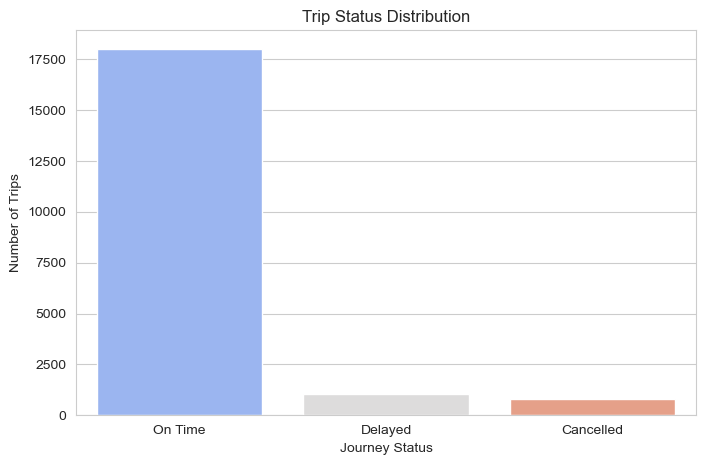

In [135]:
# Visualizing Trip Status
plt.figure(figsize=(8, 5))
sns.barplot(x=status_counts.index, y=status_counts.values, palette='coolwarm')
plt.title("Trip Status Distribution")
plt.ylabel("Number of Trips")
plt.show()

C:\Users\dramo\AppData\Local\Temp\ipykernel_2492\4119151231.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=delay_reasons.index, x=delay_reasons.values, palette='magma')


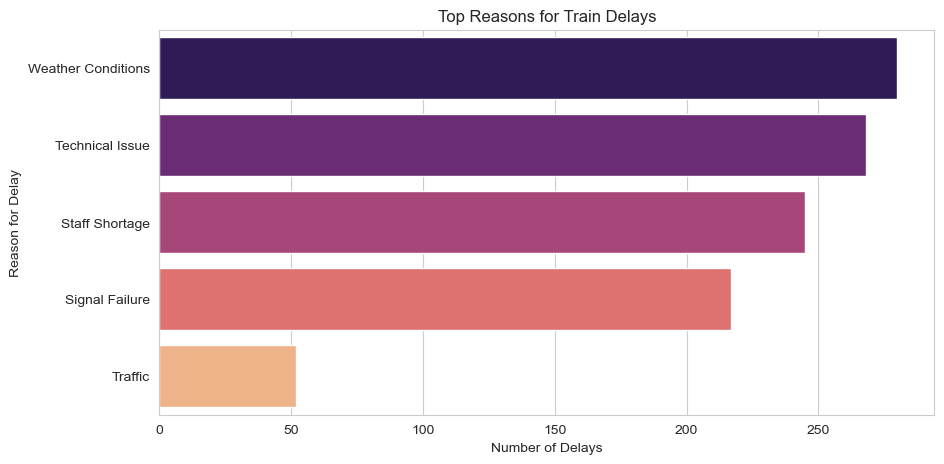

In [138]:
# Analyzing Delays by Reason
delay_reasons = trips[trips['Journey Status'] == 'Delayed']['Reason for Delay'].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(y=delay_reasons.index, x=delay_reasons.values, palette='magma')
plt.title("Top Reasons for Train Delays")
plt.xlabel("Number of Delays")
plt.show()

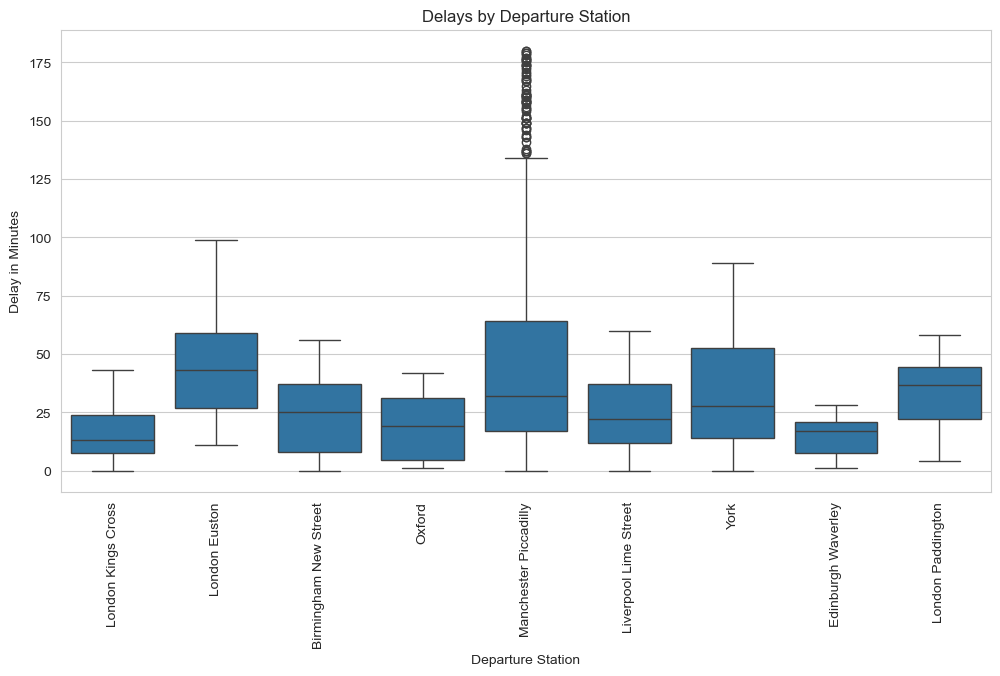

In [140]:
# Delay Analysis by Station and Route
plt.figure(figsize=(12, 6))
sns.boxplot(x='Departure Station', y='Delay in Minutes', data=trips[trips['Journey Status'] == 'Delayed'])
plt.xticks(rotation=90)
plt.title("Delays by Departure Station")
plt.show()

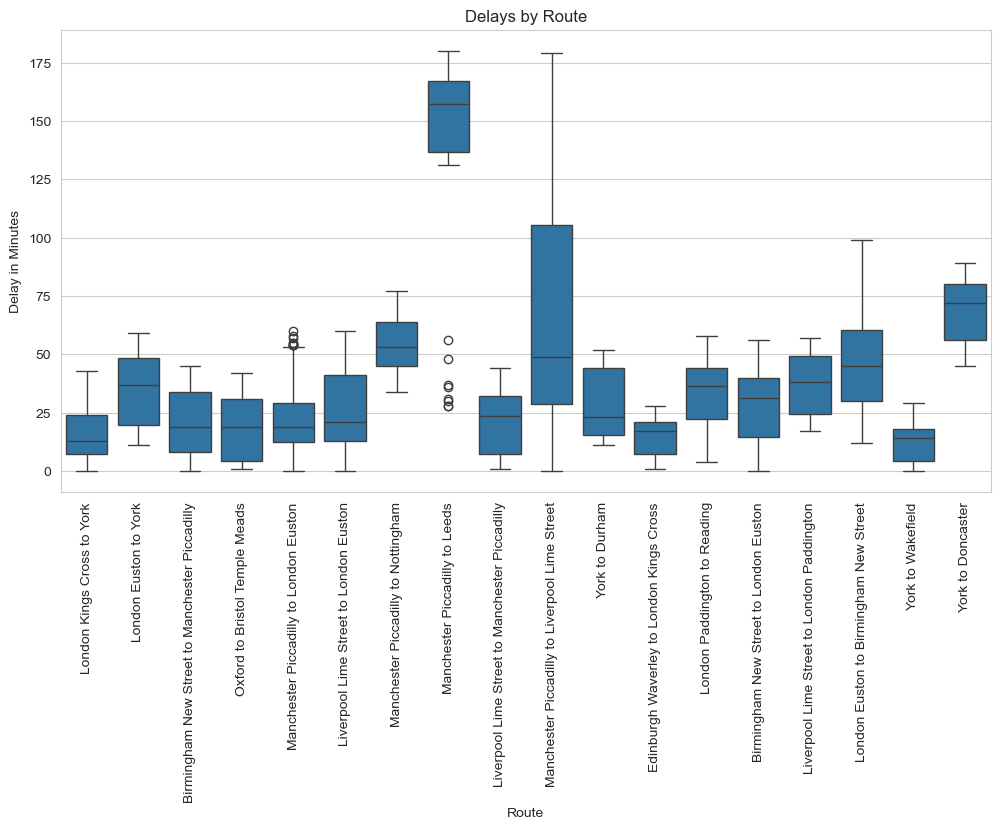

In [142]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Route', y='Delay in Minutes', data=trips[trips['Journey Status'] == 'Delayed'])
plt.xticks(rotation=90)
plt.title("Delays by Route")
plt.show()

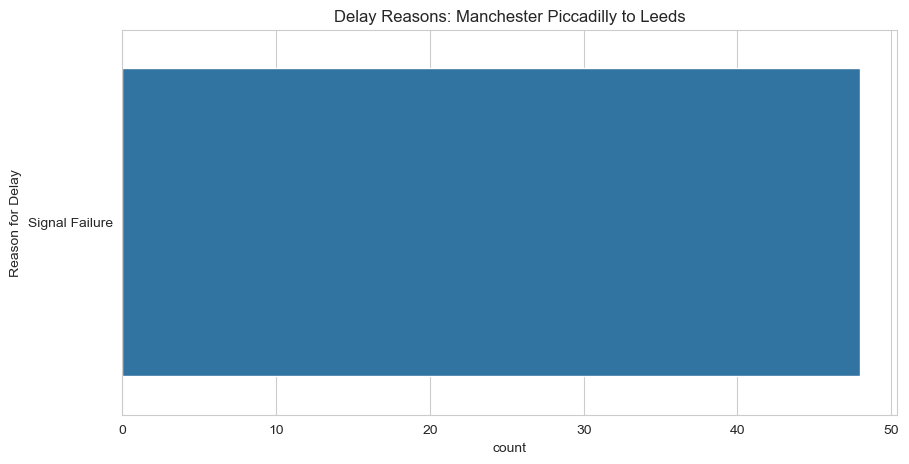

In [144]:
# Filter delayed trips for the problematic route
delayed_route = trips[
    (trips['Route'] == 'Manchester Piccadilly to Leeds') & 
    (trips['Journey Status'] == 'Delayed')
]

# Plot delay reasons (if data exists)
if 'Reason for Delay' in delayed_route.columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(
        y='Reason for Delay', 
        data=delayed_route, 
        order=delayed_route['Reason for Delay'].value_counts().index
    )
    plt.title("Delay Reasons: Manchester Piccadilly to Leeds")
    plt.show()

C:\Users\dramo\AppData\Local\Temp\ipykernel_2492\3472835736.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Departure Time', y='Delay in Minutes', data=trips[trips['Journey Status'] == 'Delayed'], palette='coolwarm')


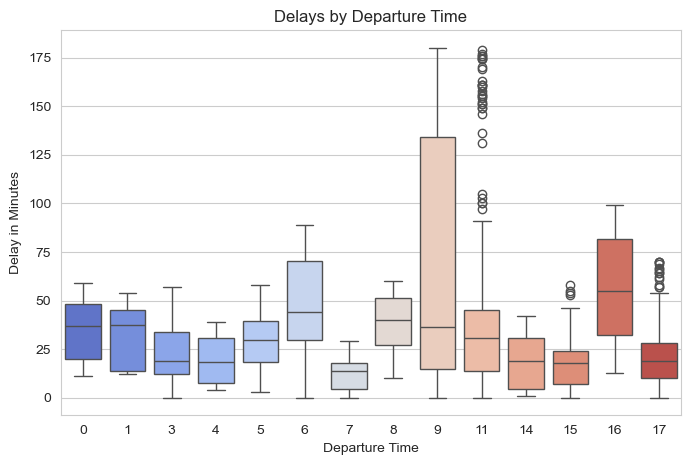

In [146]:
# Delay Analysis by Departure Time and Rush Hour
plt.figure(figsize=(8, 5))
sns.boxplot(x='Departure Time', y='Delay in Minutes', data=trips[trips['Journey Status'] == 'Delayed'], palette='coolwarm')
plt.title("Delays by Departure Time")
plt.show()

C:\Users\dramo\AppData\Local\Temp\ipykernel_2492\4080385381.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Rush Hour', y='Delay in Minutes', data=trips[trips['Journey Status'] == 'Delayed'], palette='coolwarm')


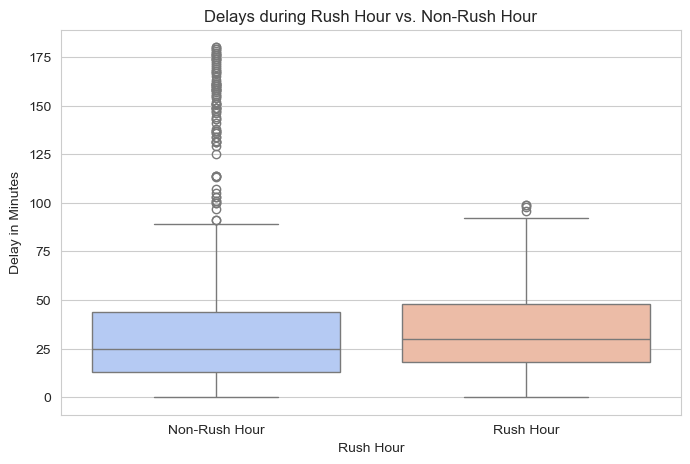

In [148]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Rush Hour', y='Delay in Minutes', data=trips[trips['Journey Status'] == 'Delayed'], palette='coolwarm')
plt.xticks([0, 1], ['Non-Rush Hour', 'Rush Hour'])
plt.title("Delays during Rush Hour vs. Non-Rush Hour")
plt.show()

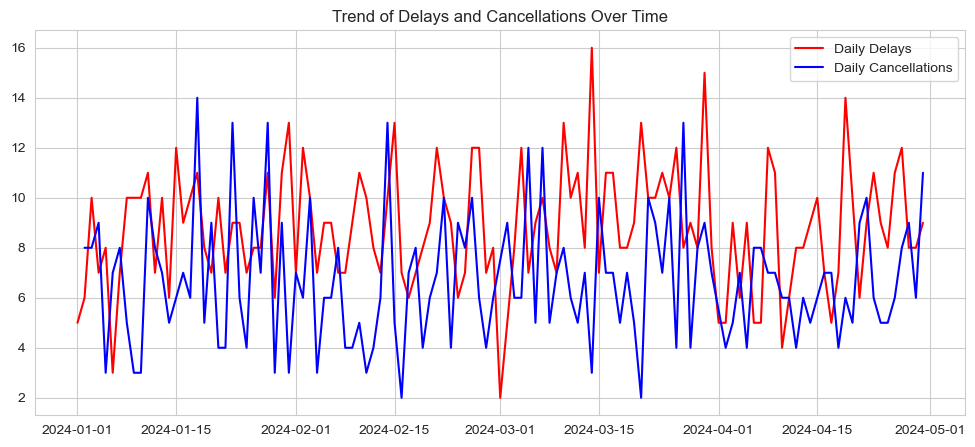

In [150]:
# Trend Analysis Over Time
daily_delays = trips[trips['Journey Status'] == 'Delayed'].groupby('Date of Journey').size()
daily_cancellations = trips[trips['Journey Status'] == 'Cancelled'].groupby('Date of Journey').size()

plt.figure(figsize=(12, 5))
plt.plot(daily_delays, label='Daily Delays', color='r')
plt.plot(daily_cancellations, label='Daily Cancellations', color='b')
plt.legend()
plt.title("Trend of Delays and Cancellations Over Time")
plt.show()

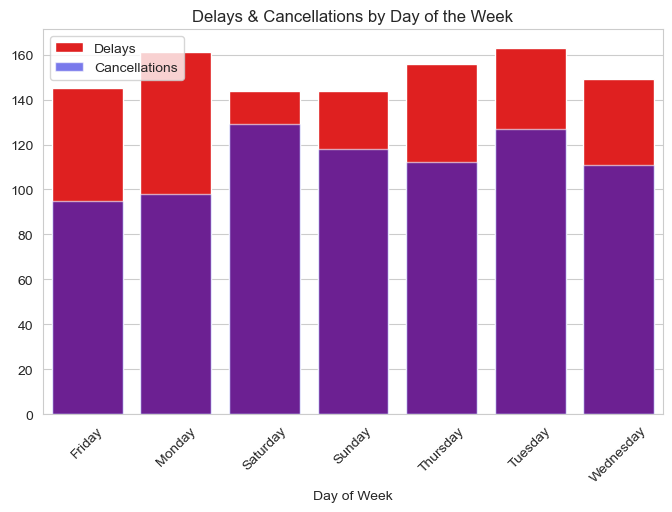

In [152]:
# Further Analysis: Weekday vs Weekend Performance
trips['Day of Week'] = trips['Date of Journey'].dt.day_name()
daywise_delays = trips[trips['Journey Status'] == 'Delayed'].groupby('Day of Week').size()
daywise_cancellations = trips[trips['Journey Status'] == 'Cancelled'].groupby('Day of Week').size()

plt.figure(figsize=(8, 5))
sns.barplot(x=daywise_delays.index, y=daywise_delays.values, color='red', label='Delays')
sns.barplot(x=daywise_cancellations.index, y=daywise_cancellations.values, color='blue', label='Cancellations', alpha=0.6)
plt.legend()
plt.title("Delays & Cancellations by Day of the Week")
plt.xticks(rotation=45)
plt.show()

In [154]:
from scipy import stats

transactions = df

# Calculate implied discount percentage
transactions['Calculated_Discount_Pct'] = (
    (transactions['Original Price'] - transactions['Price']) / 
    transactions['Original Price'] * 100
)

# Validate discount amounts match stated policies
def validate_discounts(row):
    expected_discount = 0
    # Railcard discount (1/3 off)
    if row['Railcard'] != 'No card':
        expected_discount += 33.33
    # Ticket type discounts
    if row['Ticket Type'] == 'Advance':
        expected_discount += 50
    elif row['Ticket Type'] == 'Off-Peak':
        expected_discount += 25
    # Ensure discounts don't exceed 100%
    expected_discount = min(expected_discount, 100)
    # Compare with actual
    return abs(row['Calculated_Discount_Pct'] - expected_discount) < 1  # Allow 1% tolerance

transactions['Discount_Valid'] = transactions.apply(validate_discounts, axis=1)
invalid_discounts = transactions[~transactions['Discount_Valid']]
print(f"{len(invalid_discounts)} transactions ({len(invalid_discounts)/len(transactions):.2%}) have inconsistent discounts")

8766 transactions (27.69%) have inconsistent discounts


In [158]:
discount_impact = transactions.groupby(['Ticket Type', 'Railcard']).agg(
    Total_Revenue=('Price', 'sum'),
    Potential_Revenue=('Original Price', 'sum'),
    Avg_Discount_Pct=('Calculated_Discount_Pct', 'mean'),
    Transaction_Count=('Price', 'count')
).reset_index()

discount_impact['Revenue_Loss'] = discount_impact['Potential_Revenue'] - discount_impact['Total_Revenue']
discount_impact['Revenue_Loss_Pct'] = discount_impact['Revenue_Loss'] / discount_impact['Potential_Revenue'] * 100

print(discount_impact.sort_values('Revenue_Loss', ascending=False))

   Ticket Type  Railcard  Total_Revenue  Potential_Revenue  Avg_Discount_Pct  \
2      Advance   No card         239833      479666.000000         50.000000   
0      Advance     Adult          36380      109140.000000         66.666667   
10    Off-Peak   No card         175100      233466.666667         25.000000   
1      Advance  Disabled          20533       61599.000000         66.666667   
8     Off-Peak     Adult          27163       54326.000000         50.000000   
3      Advance    Senior          12528       37584.000000         66.666667   
9     Off-Peak  Disabled          12982       25964.000000         50.000000   
4      Anytime     Adult          22787       34180.500000         33.333333   
5      Anytime  Disabled          18763       28144.500000         33.333333   
11    Off-Peak    Senior           8093       16186.000000         50.000000   
7      Anytime    Senior           8995       13492.500000         33.333333   
6      Anytime   No card         158764 

<Figure size 1400x800 with 0 Axes>

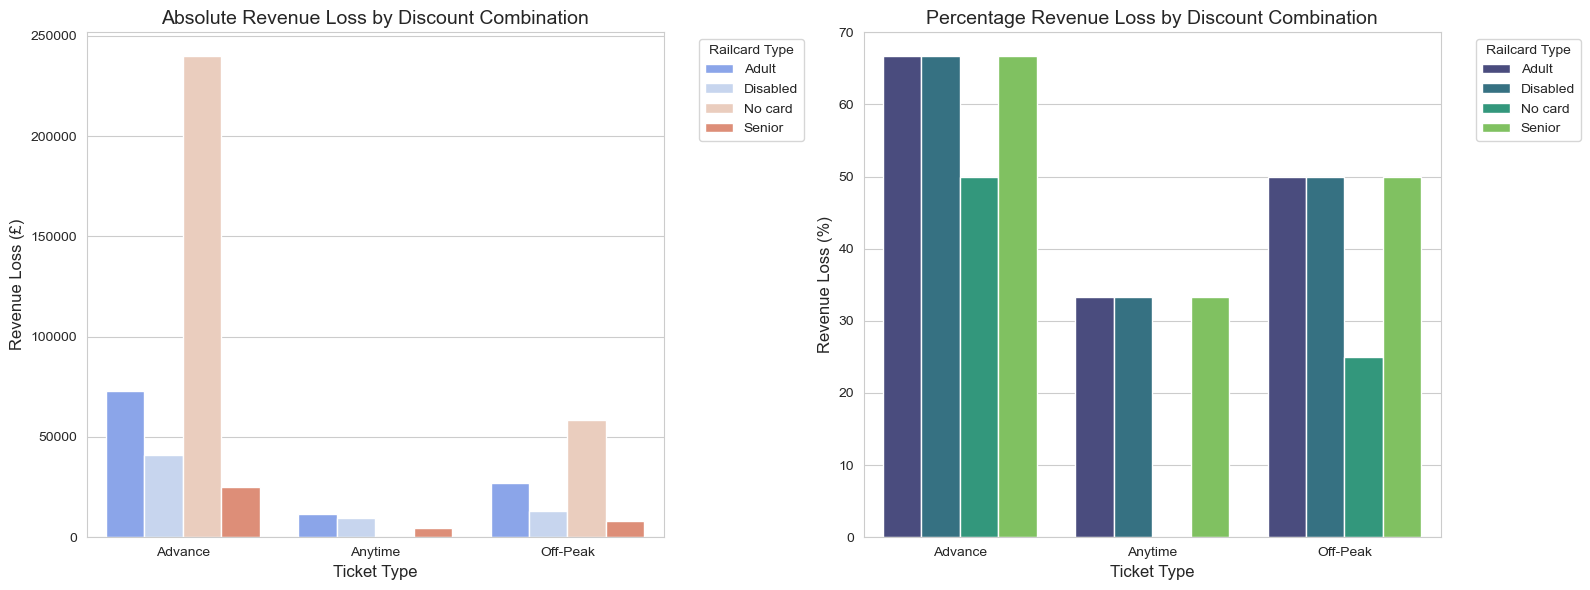

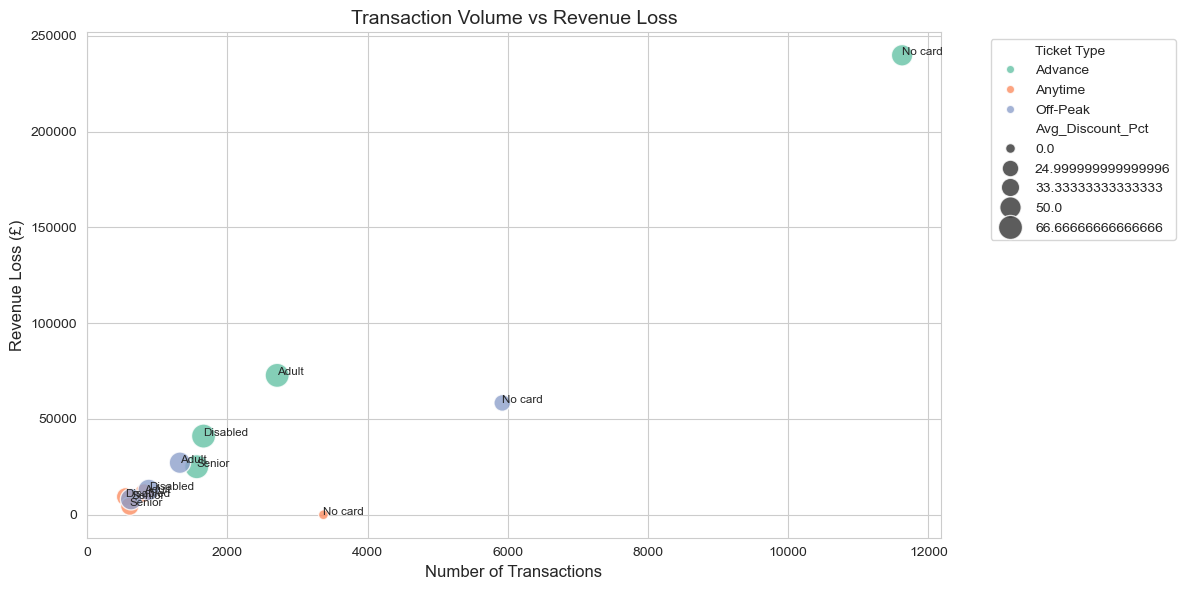

In [160]:
# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(14, 8))

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Revenue Loss by Ticket Type and Railcard
sns.barplot(
    x='Ticket Type',
    y='Revenue_Loss',
    hue='Railcard',
    data=discount_impact,
    ax=ax1,
    palette='coolwarm'
)
ax1.set_title('Absolute Revenue Loss by Discount Combination', fontsize=14)
ax1.set_ylabel('Revenue Loss (£)', fontsize=12)
ax1.set_xlabel('Ticket Type', fontsize=12)
ax1.legend(title='Railcard Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 2: Percentage Revenue Loss
sns.barplot(
    x='Ticket Type',
    y='Revenue_Loss_Pct',
    hue='Railcard',
    data=discount_impact,
    ax=ax2,
    palette='viridis'
)
ax2.set_title('Percentage Revenue Loss by Discount Combination', fontsize=14)
ax2.set_ylabel('Revenue Loss (%)', fontsize=12)
ax2.set_xlabel('Ticket Type', fontsize=12)
ax2.legend(title='Railcard Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Plot 3: Transaction Volume vs Revenue Loss
plt.figure(figsize=(12, 6))
scatter = sns.scatterplot(
    x='Transaction_Count',
    y='Revenue_Loss',
    size='Avg_Discount_Pct',
    hue='Ticket Type',
    data=discount_impact,
    sizes=(50, 300),
    palette='Set2',
    alpha=0.8
)
plt.title('Transaction Volume vs Revenue Loss', fontsize=14)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Revenue Loss (£)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add annotations
for line in range(0, discount_impact.shape[0]):
    plt.text(
        discount_impact.Transaction_Count[line]+0.01,
        discount_impact.Revenue_Loss[line],
        discount_impact.Railcard[line],
        horizontalalignment='left',
        size='small'
    )

plt.tight_layout()
plt.show()

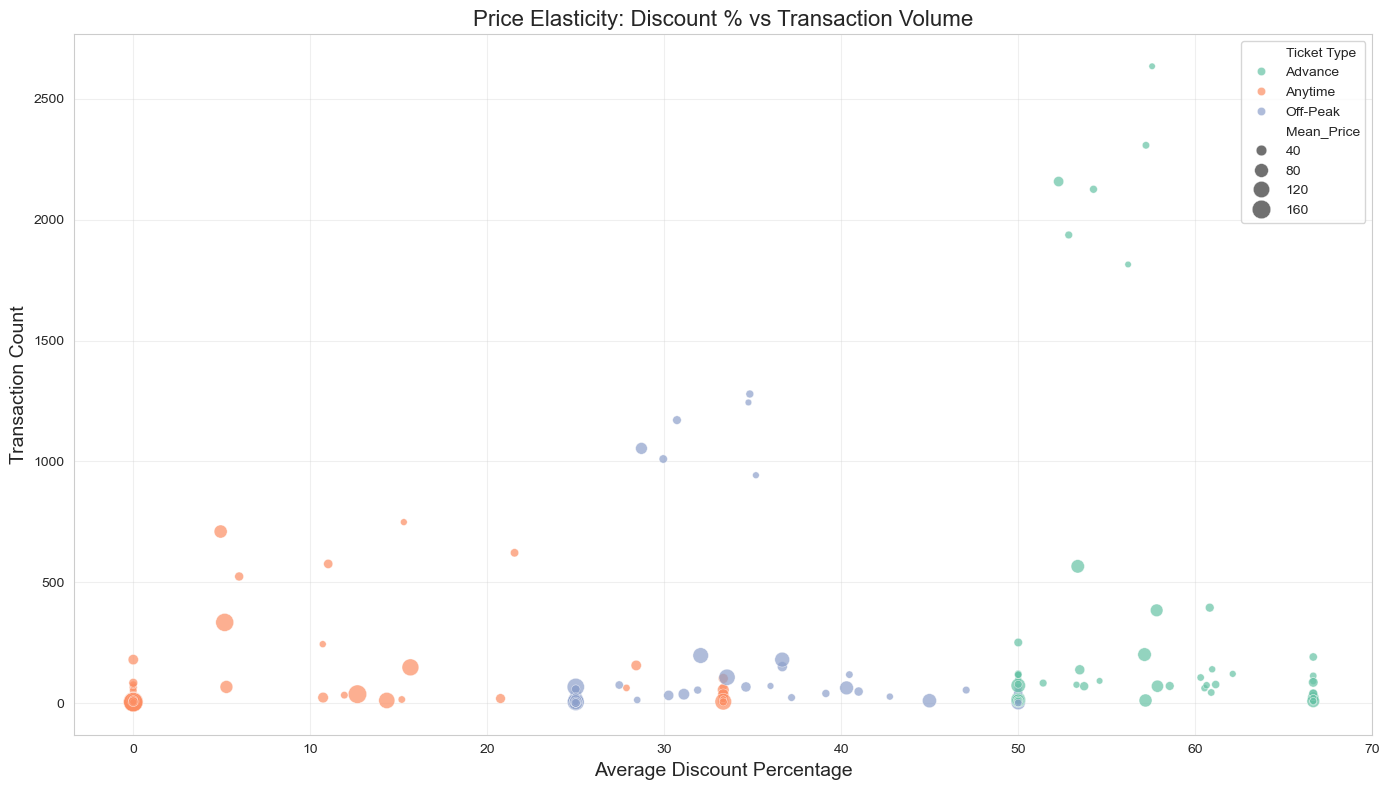

In [162]:
# Calculate price elasticity by route and ticket type
elasticity_data = transactions.groupby(['Route', 'Ticket Type']).agg(
    Mean_Price=('Price', 'mean'),
    Mean_Original=('Original Price', 'mean'),
    Transaction_Count=('Price', 'count')
).reset_index()

elasticity_data['Discount_Pct'] = (
    (elasticity_data['Mean_Original'] - elasticity_data['Mean_Price']) / 
    elasticity_data['Mean_Original'] * 100
)

# Plot elasticity
plt.figure(figsize=(14, 8))
sns.scatterplot(
    x='Discount_Pct',
    y='Transaction_Count',
    size='Mean_Price',
    hue='Ticket Type',
    data=elasticity_data,
    palette='Set2',
    sizes=(20, 200),
    alpha=0.7
)
plt.title('Price Elasticity: Discount % vs Transaction Volume', fontsize=16)
plt.xlabel('Average Discount Percentage', fontsize=14)
plt.ylabel('Transaction Count', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [164]:
elasticity_data.head()

,Route,Ticket Type,Mean_Price,Mean_Original,Transaction_Count,Discount_Pct
0,Birmingham New Street to Coventry,Advance,3.096774,6.193548,31,50.0
1,Birmingham New Street to Coventry,Anytime,5.240000,5.240000,25,0.0
2,Birmingham New Street to Coventry,Off-Peak,4.666667,6.222222,9,25.0
3,Birmingham New Street to Edinburgh,Advance,36.000000,72.000000,10,50.0
4,Birmingham New Street to Edinburgh,Off-Peak,73.000000,97.333333,6,25.0


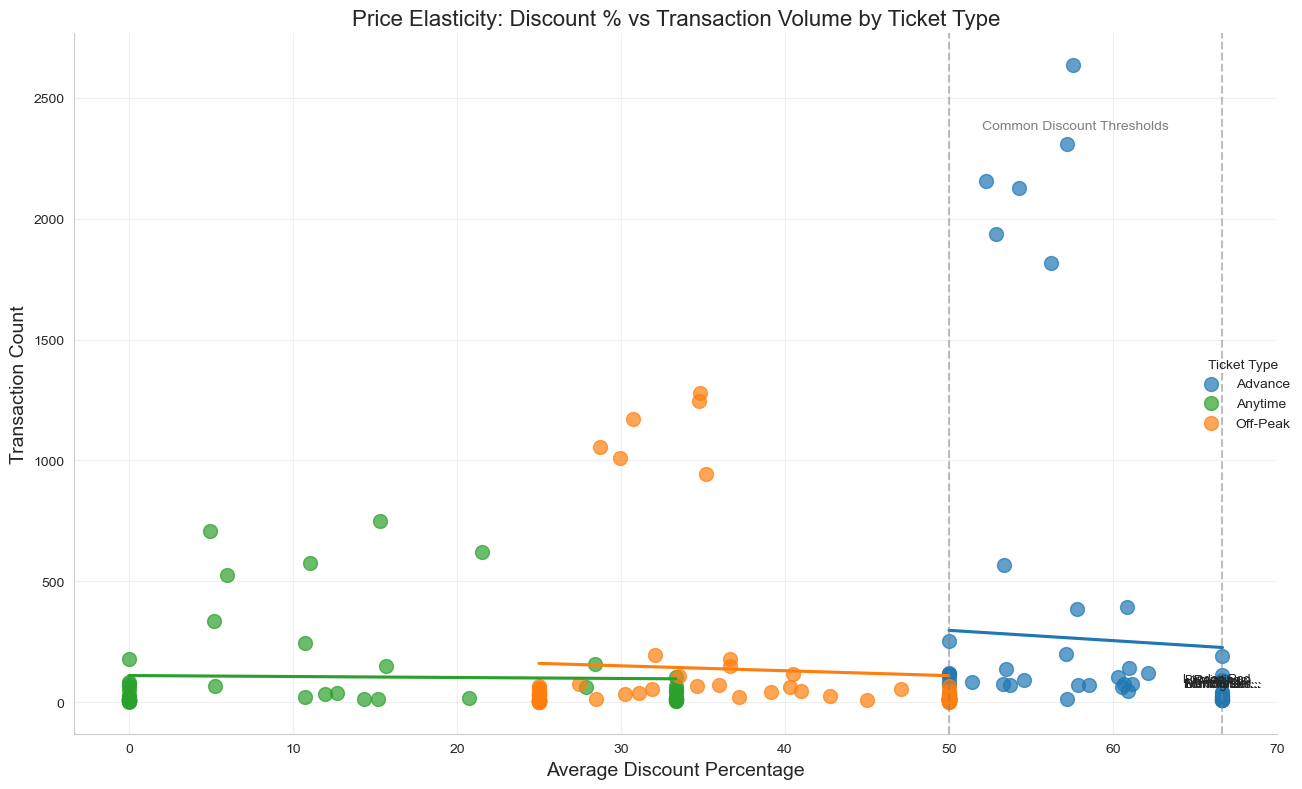

In [166]:
# Create a custom palette that highlights ticket types
palette = {'Advance': '#1f77b4', 'Off-Peak': '#ff7f0e', 'Anytime': '#2ca02c'}

# Enhanced scatter plot with regression lines
ax = sns.lmplot(
    x='Discount_Pct',
    y='Transaction_Count',
    hue='Ticket Type',
    data=elasticity_data,
    palette=palette,
    height=8,
    aspect=1.5,
    scatter_kws={'s': 100, 'alpha': 0.7},
    ci=None
)

# Add economic theory reference lines
plt.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=66.66, color='gray', linestyle='--', alpha=0.5)
plt.text(52, max(elasticity_data['Transaction_Count'])*0.9, 
         "Common Discount Thresholds", color='gray')  # Fixed parenthesis here

# Formatting
plt.title('Price Elasticity: Discount % vs Transaction Volume by Ticket Type', fontsize=16)
plt.xlabel('Average Discount Percentage', fontsize=14)
plt.ylabel('Transaction Count', fontsize=14)
plt.grid(True, alpha=0.3)

# Add annotations for special cases
outliers = elasticity_data[
    (elasticity_data['Discount_Pct'] > 60) & 
    (elasticity_data['Transaction_Count'] < elasticity_data['Transaction_Count'].median())
]
for _, row in outliers.iterrows():
    plt.annotate(
        row['Route'].split(' to ')[0][:10] + "...", 
        (row['Discount_Pct'], row['Transaction_Count']),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [168]:
# Example elasticity calculation for Advance tickets
advance_data = elasticity_data[elasticity_data['Ticket Type'] == 'Advance']
slope, _, _, _, _ = stats.linregress(advance_data['Discount_Pct'], 
                                    advance_data['Transaction_Count'])
print(f"Advance tickets: {slope:.1f} transactions per 1% discount increase")

Advance tickets: -4.3 transactions per 1% discount increase


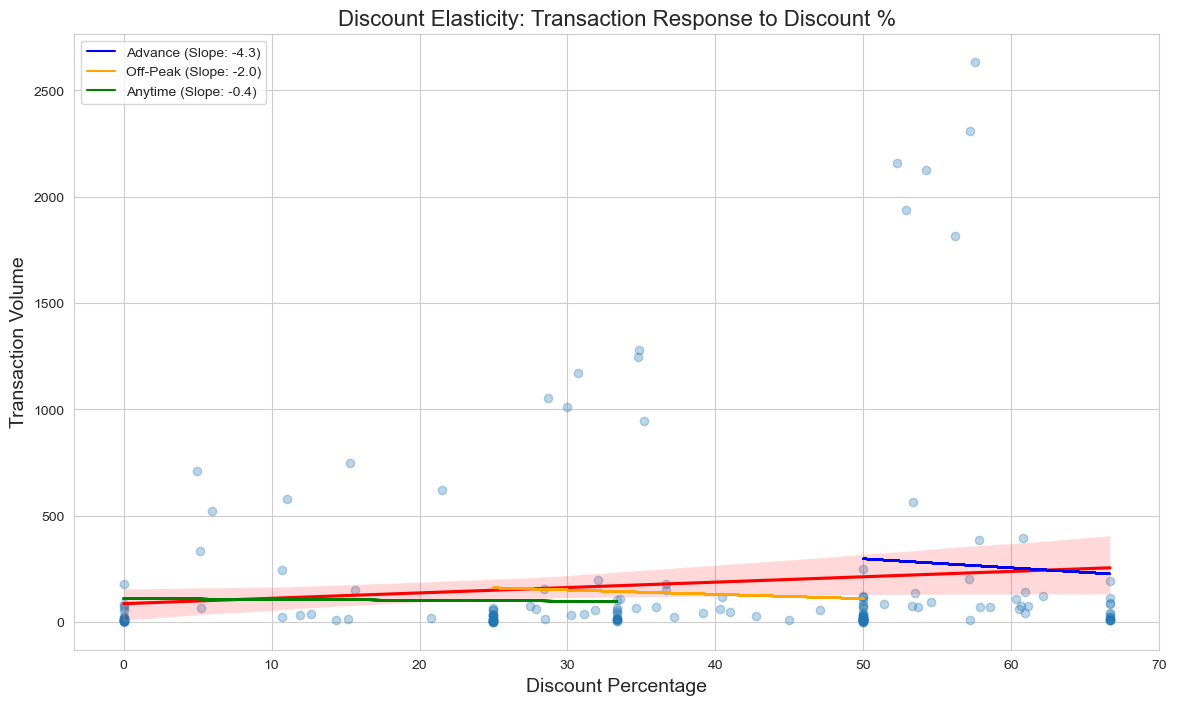

In [170]:
plt.figure(figsize=(14, 8))
sns.regplot(
    x='Discount_Pct',
    y='Transaction_Count',
    data=elasticity_data,
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)

# Add slope annotations
for ticket_type, color in [('Advance','blue'), ('Off-Peak','orange'), ('Anytime','green')]:
    subset = elasticity_data[elasticity_data['Ticket Type'] == ticket_type]
    slope, intercept = np.polyfit(subset['Discount_Pct'], subset['Transaction_Count'], 1)
    plt.plot(subset['Discount_Pct'], slope*subset['Discount_Pct'] + intercept, color=color,
             label=f'{ticket_type} (Slope: {slope:.1f})')

plt.title('Discount Elasticity: Transaction Response to Discount %', fontsize=16)
plt.xlabel('Discount Percentage', fontsize=14)
plt.ylabel('Transaction Volume', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

In [172]:
# Multinomial Logistic Regression to Analyze Factors Affecting Punctuality
trips = trips.dropna(subset=['Journey Status'])  # Remove missing journey statuses

# Encoding categorical variables
le = LabelEncoder()
trips['Journey Status Encoded'] = le.fit_transform(trips['Journey Status'])
trips['Departure Station Encoded'] = le.fit_transform(trips['Departure Station'])
trips['Route Encoded'] = le.fit_transform(trips['Route'])
trips['Day of Week Encoded'] = le.fit_transform(trips['Day of Week'])
trips['Time Category Encoded'] = le.fit_transform(trips['Time Category'])
trips['Departure Time Encoded'] = le.fit_transform(trips['Departure Time'])
trips['Rush Hour Encoded'] = le.fit_transform(trips['Rush Hour'])
trips['Arrival Destination Encoded'] = le.fit_transform(trips['Arrival Destination'])
trips['Date of Journey Encoded'] = le.fit_transform(trips['Date of Journey'])
trips['Departure Time Encoded'] = le.fit_transform(trips['Departure Time'])
trips['Day Type Encoded'] = le.fit_transform(trips['Day Type'])
trips['Time Category Encoded'] = le.fit_transform(trips['Time Category'])

# Selecting Features
features = ['Day Type Encoded', 'Departure Time Encoded', 'Date of Journey Encoded', 'Arrival Destination Encoded', 'Departure Station Encoded', 'Route Encoded', 'Day of Week Encoded', 'Time Category Encoded', 'Rush Hour Encoded']
X = trips[features].fillna(0)
y = trips['Journey Status Encoded']

In [174]:
# Multinomial Logistic Regression Model
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000, multi_class='multinomial')

In [175]:
# Displaying Feature Importance
feature_importance = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_[0]})
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)
print("Feature Importance in Predicting Punctuality:")
print(feature_importance)

Feature Importance in Predicting Punctuality:
                       Feature  Coefficient
0             Day Type Encoded     0.110758
5                Route Encoded     0.083526
6          Day of Week Encoded     0.019176
1       Departure Time Encoded     0.006102
2      Date of Journey Encoded    -0.000019
3  Arrival Destination Encoded    -0.007304
8            Rush Hour Encoded    -0.064304
7        Time Category Encoded    -0.077283
4    Departure Station Encoded    -0.359151


In [176]:
# Calculate odds ratios for top features
feature_importance['Odds_Ratio'] = np.exp(feature_importance['Coefficient'])
print(feature_importance[['Feature', 'Odds_Ratio']].sort_values('Odds_Ratio', ascending=False))

                       Feature  Odds_Ratio
0             Day Type Encoded    1.117125
5                Route Encoded    1.087113
6          Day of Week Encoded    1.019361
1       Departure Time Encoded    1.006121
2      Date of Journey Encoded    0.999981
3  Arrival Destination Encoded    0.992723
8            Rush Hour Encoded    0.937720
7        Time Category Encoded    0.925628
4    Departure Station Encoded    0.698269


In [180]:
# Identifying Departure Stations Affecting Punctuality
station_delays = trips.groupby('Departure Station')['Delay in Minutes'].mean().sort_values(ascending=False)
station_cancellations = trips[trips['Journey Status'] == 'Cancelled'].groupby('Departure Station').size().sort_values(ascending=False)

C:\Users\dramo\AppData\Local\Temp\ipykernel_2492\144482672.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


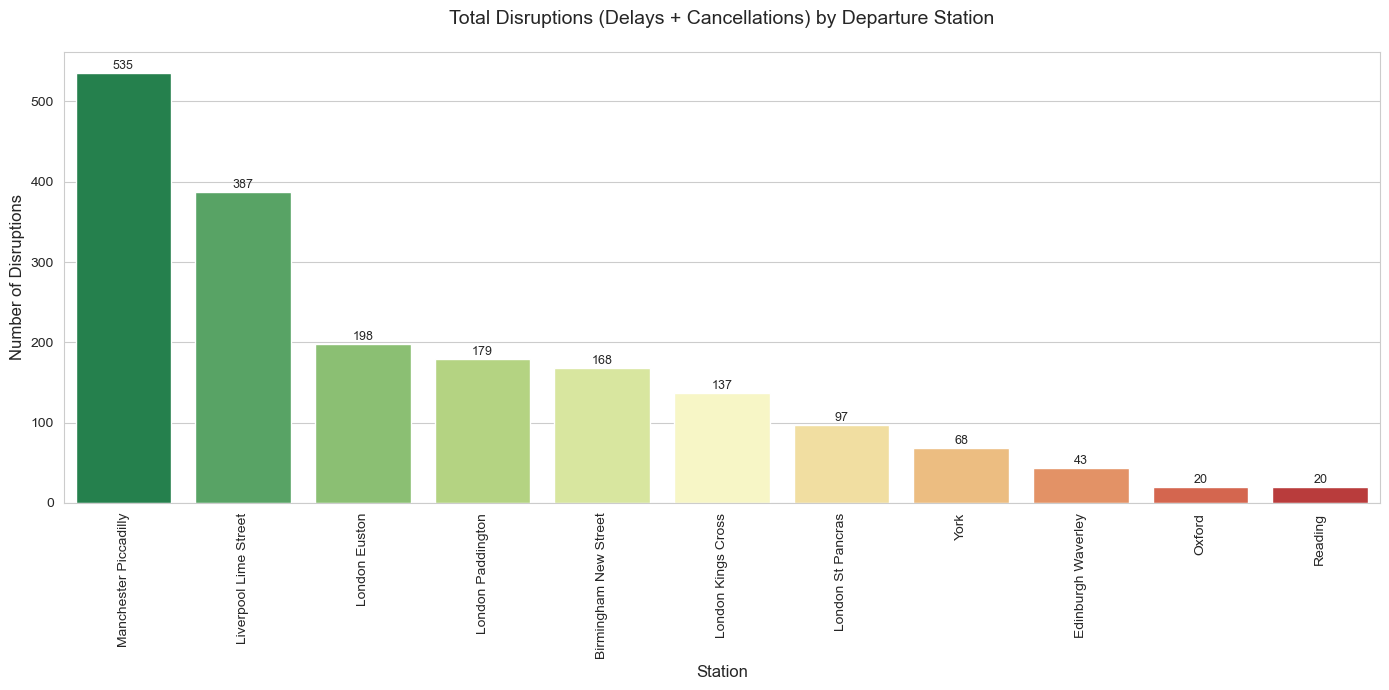

In [182]:
# Calculate total disruptions per station
station_disruptions = trips[
    trips['Journey Status'].isin(['Delayed', 'Cancelled'])
].groupby('Departure Station').size().sort_values(ascending=False)

# Plot combined disruptions
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    x=station_disruptions.index,
    y=station_disruptions.values,
    palette='RdYlGn_r',  # Red-Yellow-Green reversed for worst offenders
    order=station_disruptions.index  # Maintain sorted order
)

# Formatting
plt.title('Total Disruptions (Delays + Cancellations) by Departure Station', fontsize=14, pad=20)
plt.xlabel('Station', fontsize=12)
plt.ylabel('Number of Disruptions', fontsize=12)
plt.xticks(rotation=90)

# Add value labels
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}", 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', 
        xytext=(0, 5), 
        textcoords='offset points',
        fontsize=9
    )

plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

<Figure size 1200x700 with 0 Axes>

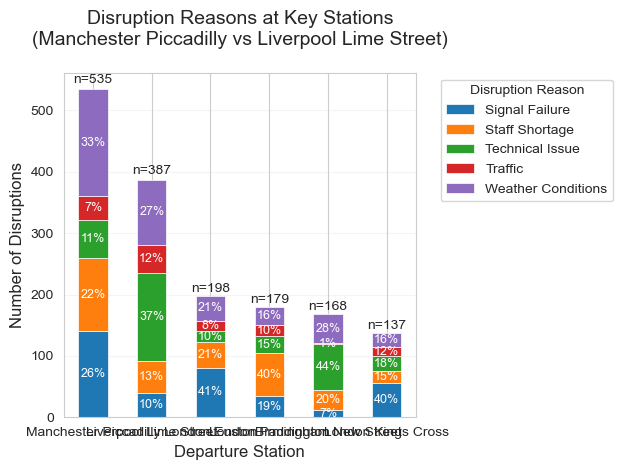

In [186]:
plt.figure(figsize=(14, 8))
# Filter and prepare the data
key_stations = ['Manchester Piccadilly', 'Liverpool Lime Street', 'London Euston', 'London Paddington', 'Birmingham New Street', 'London Kings Cross']
disruptions = trips[
    (trips['Departure Station'].isin(key_stations)) & 
    (trips['Journey Status'].isin(['Delayed', 'Cancelled']))
]
# Get reason counts - ensuring station order is preserved
reason_counts = (disruptions.groupby(['Departure Station', 'Reason for Delay'])
                 .size()
                 .unstack()
                 .reindex(key_stations)  # Force correct station order
                 .fillna(0))
# Plot with corrected orientation
plt.figure(figsize=(12, 7))
ax = reason_counts.plot(kind='bar', 
                       stacked=True, 
                       color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728','#8d6bbf'],  # Custom colors per reason
                       edgecolor='white',
                       linewidth=0.5)
# Add precise labeling
for i, station in enumerate(key_stations):
    # Total disruptions label
    total = reason_counts.loc[station].sum()
    ax.text(i, total*1.01, f"n={int(total)}", 
            ha='center', va='bottom', fontsize=10)
    # Reason percentage labels (optional)
    for j, (reason, count) in enumerate(reason_counts.loc[station].items()):
        if count > 0:
            y_pos = reason_counts.loc[station].iloc[:j+1].sum() - count/2
            pct = 100*count/total
            ax.text(i, y_pos, f"{pct:.0f}%", 
                    ha='center', va='center', 
                    color='white', fontsize=9)
# Formatting
plt.title('Disruption Reasons at Key Stations\n(Manchester Piccadilly vs Liverpool Lime Street)', 
          fontsize=14, pad=20)
plt.xlabel('Departure Station', fontsize=12)
plt.ylabel('Number of Disruptions', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Disruption Reason', 
           bbox_to_anchor=(1.05, 1), 
           loc='upper left')
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

<Figure size 3000x1500 with 0 Axes>

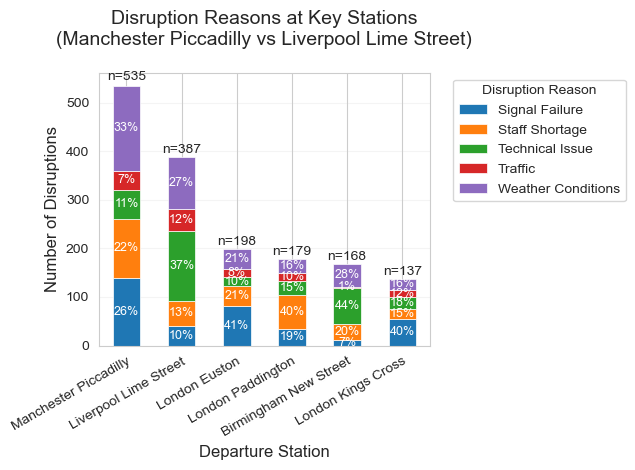

In [192]:
# Increase the figure width (adjust 15 to your preference)
plt.figure(figsize=(30, 15))

# Create the plot as before
ax = reason_counts.plot(kind='bar', 
                       stacked=True, 
                       color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728','#8d6bbf'],
                       edgecolor='white',
                       linewidth=0.5)

# Add precise labeling (same as before)
for i, station in enumerate(key_stations):
    total = reason_counts.loc[station].sum()
    ax.text(i, total*1.01, f"n={int(total)}", 
            ha='center', va='bottom', fontsize=10)
    for j, (reason, count) in enumerate(reason_counts.loc[station].items()):
        if count > 0:
            y_pos = reason_counts.loc[station].iloc[:j+1].sum() - count/2
            pct = 100*count/total
            ax.text(i, y_pos, f"{pct:.0f}%", 
                    ha='center', va='center', 
                    color='white', fontsize=9)

# Formatting
plt.title('Disruption Reasons at Key Stations\n(Manchester Piccadilly vs Liverpool Lime Street)', 
          fontsize=14, pad=20)
plt.xlabel('Departure Station', fontsize=12)
plt.ylabel('Number of Disruptions', fontsize=12)

# Make x-tick labels oblique (slanted) and adjust their position
plt.xticks(rotation=30, ha='right', rotation_mode='anchor')

plt.legend(title='Disruption Reason', 
           bbox_to_anchor=(1.05, 1), 
           loc='upper left')
plt.grid(axis='y', alpha=0.2)

# Adjust layout to prevent clipping of labels
plt.tight_layout()
plt.show()

In [194]:
# Extract hour from departure time (clean incorrect dates)
trips['Departure_Hour'] = pd.to_datetime(trips['Departure Time'], errors='coerce').dt.hour

In [222]:
# Define categorical/numerical features
categorical_features = [
    'Route', 'Departure Station', 'Arrival Destination', 
    'Day of Week', 'Time Category', 'Rush Hour', 
    'Day Type', 'Reason for Delay']  # Include delay reason!

In [223]:
numerical_features = ['Departure_Hour'] 

In [226]:
# OneHot Encoding (drop first to avoid multicollinearity)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ])

In [227]:
X = preprocessor.fit_transform(trips)
y = trips['Journey Status']  # Target: On-Time/Delayed/Cancelled

In [230]:
model = LogisticRegression(
    multi_class='multinomial', 
    solver='lbfgs', 
    max_iter=1000
)
model.fit(X, y)

LogisticRegression(max_iter=1000, multi_class='multinomial')

In [232]:
# Get feature names after OneHotEncoding
feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(input_features=categorical_features)
feature_names = list(feature_names) + numerical_features

# Check coefficients for Cancelled (class 1) and Delayed (class 2)
print("Cancelled vs. On-Time Coefficients:")
print(pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_[1]  # Change index for Delayed (2) if needed
}).sort_values('Coefficient', ascending=False))

print("\nDelayed vs. On-Time Coefficients:")
print(pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_[0]  # Adjust index based on your class mapping
}).sort_values('Coefficient', ascending=False))

Cancelled vs. On-Time Coefficients:
                                              Feature  Coefficient
121                  Reason for Delay_Technical Issue     3.308205
119                   Reason for Delay_Signal Failure     3.218339
120                   Reason for Delay_Staff Shortage     2.988968
123               Reason for Delay_Weather Conditions     2.937536
122                          Reason for Delay_Traffic     1.776075
..                                                ...          ...
90              Arrival Destination_London St Pancras    -1.075809
35   Route_London St Pancras to Birmingham New Street    -1.192254
70                Departure Station_London St Pancras    -1.322917
113                             Time Category_Evening    -2.056757
116                               Time Category_Night    -2.129274

[125 rows x 2 columns]

Delayed vs. On-Time Coefficients:
                                              Feature  Coefficient
122                          Reaso

In [234]:
from IPython.display import display, HTML

# Cancellation factors
display(HTML("<h3>Cancellation Drivers</h3>"))
display(cancel_coef.style.background_gradient(cmap='Reds', subset=['Coefficient']))

# Delay factors
display(HTML("<h3>Delay Drivers</h3>"))
display(delay_coef.style.background_gradient(cmap='Oranges', subset=['Coefficient']))

NameError: name 'cancel_coef' is not defined

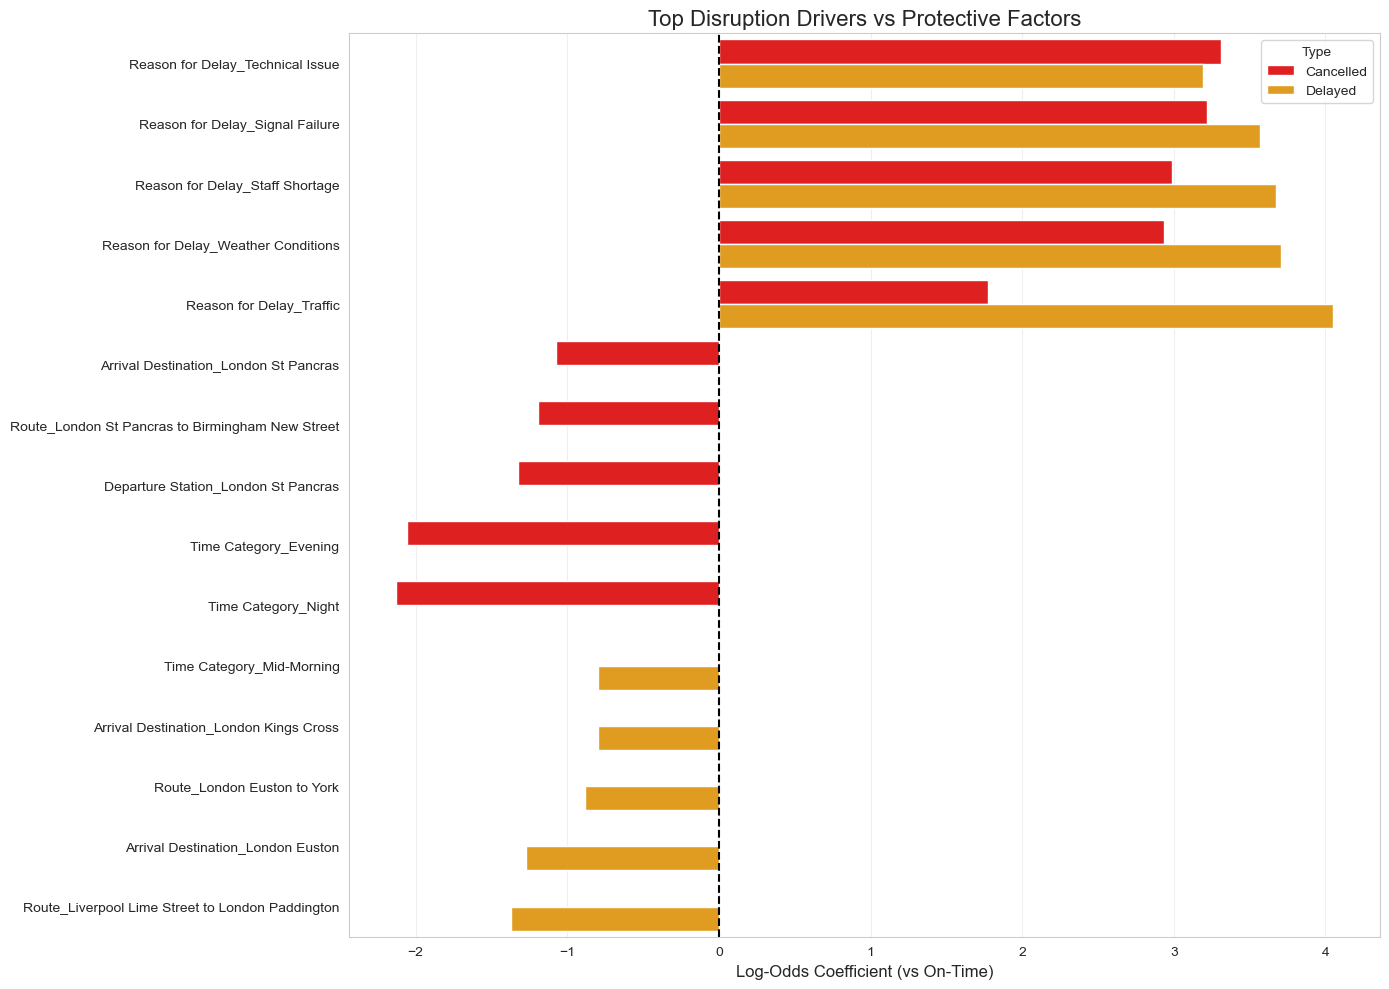

In [236]:
# Prepare DataFrames
cancel_coef = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_[1],
    'Type': 'Cancelled'
}).sort_values('Coefficient', ascending=False)

delay_coef = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_[0], 
    'Type': 'Delayed'
}).sort_values('Coefficient', ascending=False)

# Combine and filter top/bottom features
plot_data = pd.concat([
    cancel_coef.head(5),
    cancel_coef.tail(5),
    delay_coef.head(5),
    delay_coef.tail(5)
])

# Create plot
plt.figure(figsize=(14, 10))
sns.barplot(
    x='Coefficient',
    y='Feature',
    hue='Type',
    data=plot_data,
    palette={'Cancelled': 'red', 'Delayed': 'orange'},
    orient='h'
)

# Formatting
plt.title('Top Disruption Drivers vs Protective Factors', fontsize=16)
plt.xlabel('Log-Odds Coefficient (vs On-Time)', fontsize=12)
plt.ylabel('')
plt.axvline(0, color='black', linestyle='--')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [238]:
# Cross-tabulation: Reason for Delay vs. Journey Status
reason_status = pd.crosstab(
    trips['Reason for Delay'], 
    trips['Journey Status'], 
    normalize='index'  # % per row (reason)
)
print(reason_status)

Journey Status      Cancelled   Delayed  On Time
Reason for Delay                                
No delay             0.000000  0.000000      1.0
Signal Failure       0.488208  0.511792      0.0
Staff Shortage       0.439359  0.560641      0.0
Technical Issue      0.281501  0.718499      0.0
Traffic              0.657895  0.342105      0.0
Weather Conditions   0.399142  0.600858      0.0


In [240]:
routes = pd.read_csv('routes.csv')

In [242]:
transactions = df
df2 = pd.merge(transactions, routes, on='Route')

In [244]:
# Validate discounts
df2['Expected_Price'] = df2.apply(lambda row: (
    row['Original Price'] * 0.67 if row['Railcard'] in ['Adult', 'Senior', 'Disabled'] else row['Original Price']
) * (0.5 if row['Ticket Type'] == 'Advance' else 0.75 if row['Ticket Type'] == 'Off-Peak' else 1), axis=1)

In [246]:
df2['Discount_Error'] = abs(df2['Price'] - df2['Expected_Price'])
anomalies = df2[df2['Discount_Error'] > 0.1]  # Adjust threshold
print(anomalies)

                Transaction ID Date of Purchase Time of Purchase  \
0      da8a6ba8-b3dc-4677-b176       2023-12-08         12:41:11   
1      b0cdd1b0-f214-4197-be53       2023-12-16         11:23:01   
22     d4ea6940-7228-41ef-9eae       2023-12-31         13:33:39   
26     74462231-5241-46f4-8328       2023-12-31         15:53:46   
46     a9b958eb-96a2-482c-a58b       2024-01-01         05:14:54   
...                        ...              ...              ...   
31576  0867426f-679a-40de-9888       2024-04-30         06:37:09   
31585  a3faa0ea-baab-4837-874e       2024-04-30         07:48:22   
31637  5dd5c27f-fd92-42c5-95f9       2024-04-30         17:05:54   
31639  465e3643-fb67-4deb-8ec9       2024-04-30         17:13:32   
31641  2e96cde6-50c1-4311-8089       2024-04-30         17:16:04   

      Purchase Type Payment Method  Railcard Ticket Class Ticket Type  Price  \
0            Online    Contactless     Adult     Standard     Advance     43   
1           Station    

In [248]:
# Convert to hour
df2['Departure Hour'] = pd.to_datetime(df2['Departure Time'], format='%H:%M:%S').dt.hour

# Define peak hours (6-9am OR 4-7pm)
morning_peak = (df2['Departure Hour'] >= 6) & (df2['Departure Hour'] <= 8)
evening_peak = (df2['Departure Hour'] >= 16) & (df2['Departure Hour'] <= 18)
peak_hours = morning_peak | evening_peak

# Find invalid Off-Peak tickets
invalid_off_peak = df2[
    (df2['Ticket Type'] == 'Off-Peak') & 
    peak_hours & 
    (df2['Day Type'] == 'Weekday')
]

In [250]:
print(invalid_off_peak)

Empty DataFrame
Columns: [Transaction ID, Date of Purchase, Time of Purchase, Purchase Type, Payment Method, Railcard, Ticket Class, Ticket Type, Price, Departure Station_x, Arrival Destination_x, Date of Journey, Departure Time, Arrival Time, Actual Arrival Time, Journey Status, Reason for Delay, Refund Request, Route, Arrival DateTime, Actual Arrival DateTime, Delay in Minutes, Trip ID, Day Type, Original Price, Discounted Ammount, Calculated_Discount_Pct, Discount_Valid, Departure Station_y, Arrival Destination_y, mileage, Distance, CO2e emissionss, Expected_Price, Discount_Error, Departure Hour]
Index: []

[0 rows x 36 columns]


In [252]:
# doing regression analysis to obtain elasticity
# Aggregate data to daily level
daily_data = df2.groupby('Date of Purchase').agg({
    'Price': 'sum',          # Daily revenue
    'Original Price': 'mean', # Average original price
    'Transaction ID': 'count' # Number of tickets sold (volume)
}).rename(columns={'Transaction ID': 'Volume'}).reset_index()

# Calculate % changes
daily_data['Price_Change_Pct'] = daily_data['Original Price'].pct_change() * 100
daily_data['Volume_Change_Pct'] = daily_data['Volume'].pct_change() * 100
daily_data = daily_data.dropna()  # Remove first row with NaN
print(daily_data)

    Date of Purchase  Price  Original Price  Volume  Price_Change_Pct  \
1         2023-12-16     23       69.000000       1        -46.511628   
2         2023-12-19      3        6.000000       1        -91.304348   
3         2023-12-20     13       26.000000       1        333.333333   
4         2023-12-27     76      152.000000       1        484.615385   
5         2023-12-30     35       70.000000       1        -53.947368   
..               ...    ...             ...     ...               ...   
123       2024-04-26   6008       36.389100     263          7.373092   
124       2024-04-27   6767       42.684915     274         17.301375   
125       2024-04-28   6431       39.826190     280         -6.697271   
126       2024-04-29   6051       34.500611     273        -13.372055   
127       2024-04-30   3729       37.961640     126         10.031793   

     Volume_Change_Pct  
1             0.000000  
2             0.000000  
3             0.000000  
4             0.000000 

In [254]:
# Define variables
X = daily_data['Price_Change_Pct']  # Independent variable (% price change)
y = daily_data['Volume_Change_Pct']  # Dependent variable (% volume change)

# Add constant (intercept term)
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X).fit()
print(model.summary())

# Extract elasticity
elasticity = model.params['Price_Change_Pct']
print(f"\nPrice Elasticity of Demand: {elasticity:.2f}")

                            OLS Regression Results                            
Dep. Variable:      Volume_Change_Pct   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9312
Date:                Thu, 10 Apr 2025   Prob (F-statistic):              0.336
Time:                        09:46:53   Log-Likelihood:                -879.61
No. Observations:                 127   AIC:                             1763.
Df Residuals:                     125   BIC:                             1769.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               33.7453     22.142  

In [256]:
import statsmodels.api as sm

# Filter data to remove outliers/invalid values
daily_data = daily_data[
    (daily_data['Volume'] >= 5) &  # Minimum transaction threshold
    (daily_data['Price_Change_Pct'].between(-100, 100))  # Remove extreme % changes
]

# GLM with Gamma family (for positive continuous data) and log link
glm_model = sm.GLM(
    endog=daily_data['Volume'],  # Use raw volume (not % change)
    exog=sm.add_constant(daily_data['Original Price']),  # Use raw price
    family=sm.families.Gamma(link=sm.families.links.Log())  # Log-link for elasticity interpretation
).fit()

print(glm_model.summary())

# Calculate elasticity (derivative of log-link)
elasticity = glm_model.params['Original Price'] * np.mean(daily_data['Original Price'])
print(f"\nPrice Elasticity of Demand: {elasticity:.3f}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Volume   No. Observations:                  122
Model:                            GLM   Df Residuals:                      120
Model Family:                   Gamma   Df Model:                            1
Link Function:                    Log   Scale:                         0.10906
Method:                          IRLS   Log-Likelihood:                -753.06
Date:                Thu, 10 Apr 2025   Deviance:                       23.721
Time:                        09:47:20   Pearson chi2:                     13.1
No. Iterations:                    10   Pseudo R-squ. (CS):          6.737e-05
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              5.5968      0.403     13.

In [258]:
# More forgiving transformation
daily_data['asinh_Volume'] = np.arcsinh(daily_data['Volume'])
daily_data['asinh_Price'] = np.arcsinh(daily_data['Original Price'])

model = sm.OLS(
    daily_data['asinh_Volume'],
    sm.add_constant(daily_data['asinh_Price'])
).fit()
print(model.summary())

# Extract elasticity
elasticity = model.params['asinh_Price']
print(f"\nPrice Elasticity of Demand: {elasticity:.2f}")

                            OLS Regression Results                            
Dep. Variable:           asinh_Volume   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.008
Method:                 Least Squares   F-statistic:                   0.03201
Date:                Thu, 10 Apr 2025   Prob (F-statistic):              0.858
Time:                        09:47:24   Log-Likelihood:                -96.769
No. Observations:                 122   AIC:                             197.5
Df Residuals:                     120   BIC:                             203.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           6.6588      2.820      2.361      

In [260]:
# Predictive analysis
# 1. Current metrics
current_advance = df2[df2['Ticket Type'] == 'Advance']
current_advance_revenue = current_advance['Price'].sum()
current_total_revenue = df2['Price'].sum()
advance_share = current_advance_revenue / current_total_revenue

In [261]:
# 2. Scenario parameters
new_discount = 0.4  # Reducing discount from 50% to 40%
price_increase_pct = (0.5 - new_discount)/0.5  # 20% price increase

In [302]:
# 3. Elasticity (from your regression or industry standard)
elasticity = -0.038  # Adjust based on your data
expected_volume_change = price_increase_pct * elasticity  

In [304]:
# 4. Calculate new revenue
new_advance_revenue = current_advance_revenue * (1 + price_increase_pct) * (1 + expected_volume_change)
revenue_change = new_advance_revenue - current_advance_revenue

print(f"""
Current Advance Revenue: £{current_advance_revenue:,.2f}
After 20% price increase & {abs(expected_volume_change*100):.1f}% volume drop:
New Advance Revenue: £{new_advance_revenue:,.2f} ({revenue_change:+,.2f})
""")


Current Advance Revenue: £309,274.00
After 20% price increase & 0.8% volume drop:
New Advance Revenue: £368,308.22 (+59,034.22)



In [268]:
# Tickets analysis
# Revenue Comparison: Discounted vs. Non-Discounted
transactions = df
transactions['Discount Applied'] = transactions['Discounted Ammount'] > 0

revenue_comparison = transactions.groupby('Discount Applied')[['Original Price', 'Discounted Ammount']].sum()
print(revenue_comparison)

                  Original Price  Discounted Ammount
Discount Applied                                    
False               1.587640e+05            0.000000
True                1.093749e+06       510592.166667


C:\Users\dramo\AppData\Local\Temp\ipykernel_2492\1046500862.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_discount.index, y=sales_by_discount.values, palette='coolwarm')


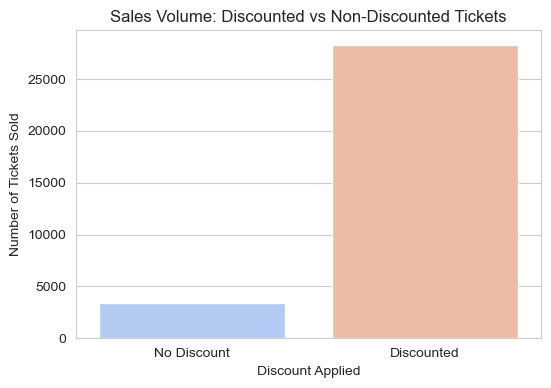

In [270]:
# Sales Volume Analysis
sales_by_discount = transactions.groupby('Discount Applied').size()
plt.figure(figsize=(6,4))
sns.barplot(x=sales_by_discount.index, y=sales_by_discount.values, palette='coolwarm')
plt.xticks([0, 1], ['No Discount', 'Discounted'])
plt.ylabel('Number of Tickets Sold')
plt.title('Sales Volume: Discounted vs Non-Discounted Tickets')
plt.show()

C:\Users\dramo\AppData\Local\Temp\ipykernel_2492\3864217557.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Ticket Type', y='Discounted Ammount', data=transactions, palette='viridis')


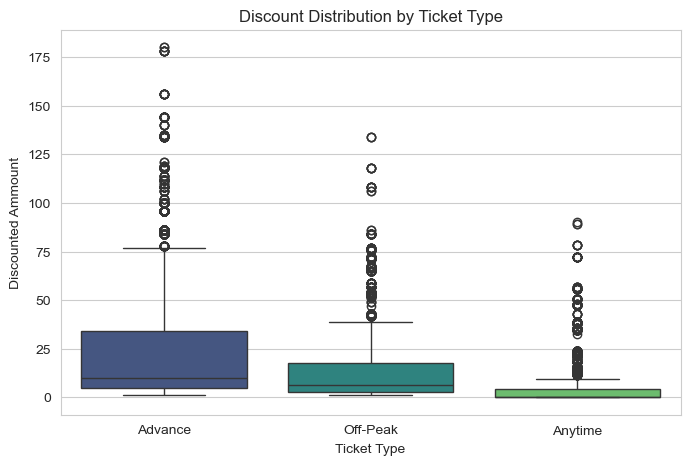

In [272]:
# Impact of Different Discount Types
plt.figure(figsize=(8,5))
sns.boxplot(x='Ticket Type', y='Discounted Ammount', data=transactions, palette='viridis')
plt.title('Discount Distribution by Ticket Type')
plt.show()

In [274]:
# Seasonality Impact
transactions['Date of Purchase'] = pd.to_datetime(transactions['Date of Journey'])
transactions['Month'] = transactions['Date of Journey'].dt.month

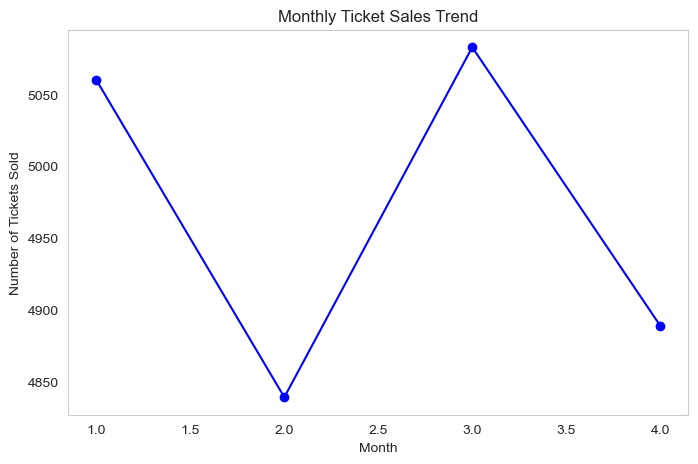

In [276]:
monthly_sales = transactions.groupby('Month').size()
plt.figure(figsize=(8,5))
plt.plot(monthly_sales, marker='o', linestyle='-', color='b')
plt.xlabel('Month')
plt.ylabel('Number of Tickets Sold')
plt.title('Monthly Ticket Sales Trend')
plt.grid()
plt.show()

In [282]:
# Calculate Base Price per KM
# Merge transactions with route distances
df_merged = pd.merge(df2, routes, on='Route')

# Calculate current price per km
df_merged['Price_per_100km'] = df_merged['Original Price'] / (df_merged['Distance_y']/100)

# Identify outlier routes
price_stats = df_merged.groupby('Route')['Price_per_100km'].describe()
high_variance_routes = price_stats[price_stats['std'] > price_stats['mean'].quantile(0.75)]
price_stats.head(65)

,count,mean,std,min,25%,50%,75%,max
Route,,,,,,,,
Birmingham New Street to Coventry,65.0,18.961235,3.036602,16.259634,16.259634,19.511561,19.511561,26.015414
Birmingham New Street to Edinburgh,16.0,15.662475,4.988727,13.836787,13.836787,13.836787,13.836787,28.442285
Birmingham New Street to Liverpool Lime Street,175.0,12.653191,16.769783,6.198783,6.818661,7.438539,7.438539,64.467339
Birmingham New Street to London Euston,125.0,24.944182,10.377935,20.980216,21.411908,21.757261,21.757261,56.983304
Birmingham New Street to London Kings Cross,17.0,29.247155,14.635094,22.274224,22.274224,23.042301,23.042301,59.909981
...,...,...,...,...,...,...,...,...
York to Edinburgh Waverley,15.0,14.111980,0.180772,13.822369,14.019831,14.217294,14.217294,14.217294
York to Leeds,17.0,15.652156,7.550894,13.453820,13.453820,13.453820,14.948689,44.846066
York to Liverpool Lime Street,15.0,18.385365,0.105335,18.358168,18.358168,18.358168,18.358168,18.766127


In [284]:
from IPython.display import display, HTML

# Creates scrollable output in Jupyter
display(HTML(price_stats.to_html()))

,count,mean,std,min,25%,50%,75%,max
Route,,,,,,,,
Birmingham New Street to Coventry,65.0,18.961235,3.036602e+00,16.259634,16.259634,19.511561,19.511561,26.015414
Birmingham New Street to Edinburgh,16.0,15.662475,4.988727e+00,13.836787,13.836787,13.836787,13.836787,28.442285
Birmingham New Street to Liverpool Lime Street,175.0,12.653191,1.676978e+01,6.198783,6.818661,7.438539,7.438539,64.467339
Birmingham New Street to London Euston,125.0,24.944182,1.037794e+01,20.980216,21.411908,21.757261,21.757261,56.983304
Birmingham New Street to London Kings Cross,17.0,29.247155,1.463509e+01,22.274224,22.274224,23.042301,23.042301,59.909981
Birmingham New Street to London Paddington,32.0,25.986442,1.420804e+01,20.183644,20.183644,20.990990,20.990990,62.972970
Birmingham New Street to London St Pancras,702.0,27.673854,1.227212e+01,22.839082,23.101600,23.101600,23.626636,61.954290
Birmingham New Street to Manchester Piccadilly,224.0,17.418501,7.382914e+00,14.557453,14.557453,15.250665,15.597272,40.206300
Birmingham New Street to Nuneaton,219.0,33.966589,8.532387e+00,30.241701,30.241701,32.567986,32.567986,65.135971


In [286]:
print(high_variance_routes)

Empty DataFrame
Columns: [count, mean, std, min, 25%, 50%, 75%, max]
Index: []


In [288]:
df_merged.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station_x,...,CO2e emissionss_x,Expected_Price,Discount_Error,Departure Hour,Departure Station,Arrival Destination,mileage_y,Distance_y,CO2e emissionss_y,Price_per_100km
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,...,12.459677,43.215,0.215,11,London Paddington,Liverpool Lime Street,209.5,337.295,12.459677,38.245453
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,...,12.418046,23.115,0.115,9,London Kings Cross,York,208.8,336.168,12.418046,20.525452
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,No card,Standard,Advance,3,Liverpool Lime Street,...,2.039938,3.000,0.000,18,Liverpool Lime Street,Manchester Piccadilly,34.3,55.223,2.039938,10.865038
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,No card,Standard,Advance,13,London Paddington,...,2.444357,13.000,0.000,21,London Paddington,Reading,41.1,66.171,2.444357,39.292137
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,No card,Standard,Advance,76,Liverpool Lime Street,...,12.614308,76.000,0.000,16,Liverpool Lime Street,London Euston,212.1,341.481,12.614308,44.511993


In [290]:
routes.head()

,Departure Station,Arrival Destination,Route,mileage,Distance,CO2e emissionss
0,London Paddington,Liverpool Lime Street,London Paddington to Liverpool Lime Street,209.5,337.295,12.459677
1,London Kings Cross,York,London Kings Cross to York,208.8,336.168,12.418046
2,Liverpool Lime Street,Manchester Piccadilly,Liverpool Lime Street to Manchester Piccadilly,34.3,55.223,2.039938
3,London Paddington,Reading,London Paddington to Reading,41.1,66.171,2.444357
4,Liverpool Lime Street,London Euston,Liverpool Lime Street to London Euston,212.1,341.481,12.614308


In [292]:
# Multi-Factor Pricing Model
# Feature Engineering
pricing_factors = df_merged.groupby('Route').agg({
    'Distance_y': 'first',
    'Transaction ID': 'count',  # Demand
    'Railcard': lambda x: (x != 'None').mean(),  # Premium customer ratio
    'Ticket Class': lambda x: (x == 'First Class').mean()  # Service level
}).rename(columns={
    'Transaction ID': 'Demand',
    'Railcard': 'Premium_Customer_Ratio',
    'Ticket Class': 'First_Class_Ratio'
})

# Target: Current price/km (median to reduce outlier impact)
pricing_factors['Target_Price_per_100km'] = df_merged.groupby('Route')['Price_per_100km'].median()

# Train pricing model
model = LinearRegression()
X = pricing_factors[['Distance_y', 'Demand', 'Premium_Customer_Ratio', 'First_Class_Ratio']]
y = pricing_factors['Target_Price_per_100km']
model.fit(X, y)

# Generate fair prices
pricing_factors['Fair_Price_per_100km'] = model.predict(X)

In [294]:
# Price Adjustment Algorithm
# Calculate adjustment ratios
pricing_factors['Adjustment_Ratio'] = (
    pricing_factors['Fair_Price_per_100km'] / 
    pricing_factors['Target_Price_per_100km']
)

# Apply smoothing to avoid extreme changes
def smooth_adjustment(ratio):
    if ratio < 0.8:
        return 0.8  # Prevent >20% price cuts
    elif ratio > 1.2:
        return 1.2  # Prevent >20% price hikes
    return ratio

pricing_factors['Smoothed_Ratio'] = pricing_factors['Adjustment_Ratio'].apply(smooth_adjustment)

# Generate final prices
pricing_factors['Adjusted_Price'] = (
    pricing_factors['Target_Price_per_100km'] * 
    pricing_factors['Smoothed_Ratio'] * 
    pricing_factors['Distance_y']
)

In [296]:
# Demand tiers (percentiles)
demand_tiers = pricing_factors['Demand'].quantile([0.3, 0.7])
pricing_factors['Demand_Tier'] = pd.cut(
    pricing_factors['Demand'],
    bins=[0, *demand_tiers, float('inf')],
    labels=['Low', 'Medium', 'High']
)

# Apply tier multipliers
tier_multipliers = {'Low': 0.9, 'Medium': 1.0, 'High': 1.15}
pricing_factors['Final_Price'] = pricing_factors.apply(
    lambda row: row['Adjusted_Price'] * tier_multipliers[row['Demand_Tier']],
    axis=1
)

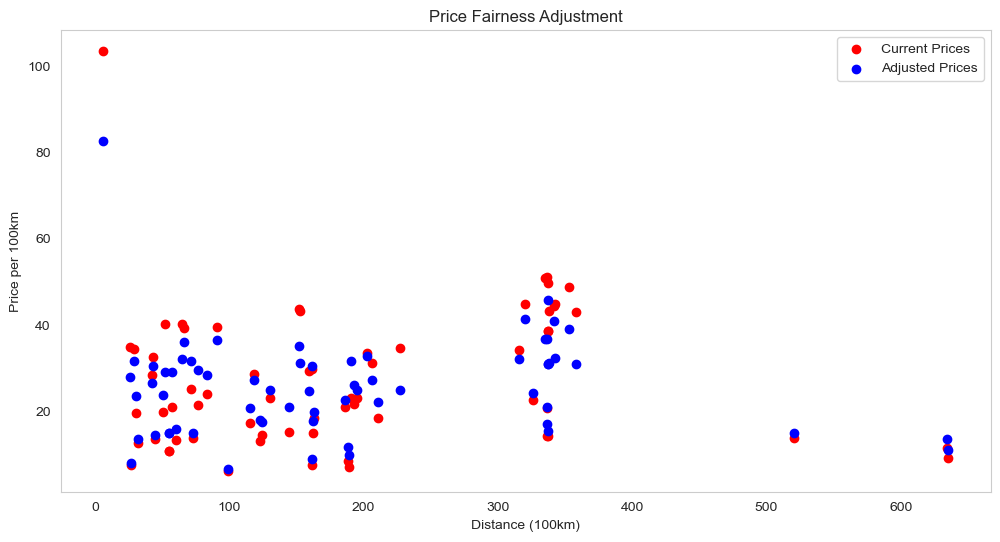

In [298]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.scatter(
    pricing_factors['Distance_y'],
    pricing_factors['Target_Price_per_100km'],
    c='red', label='Current Prices'
)
plt.scatter(
    pricing_factors['Distance_y'],
    pricing_factors['Final_Price'] / pricing_factors['Distance_y'],
    c='blue', label='Adjusted Prices'
)
plt.xlabel('Distance (100km)')
plt.ylabel('Price per 100km')
plt.title('Price Fairness Adjustment')
plt.legend()
plt.grid()
plt.show()

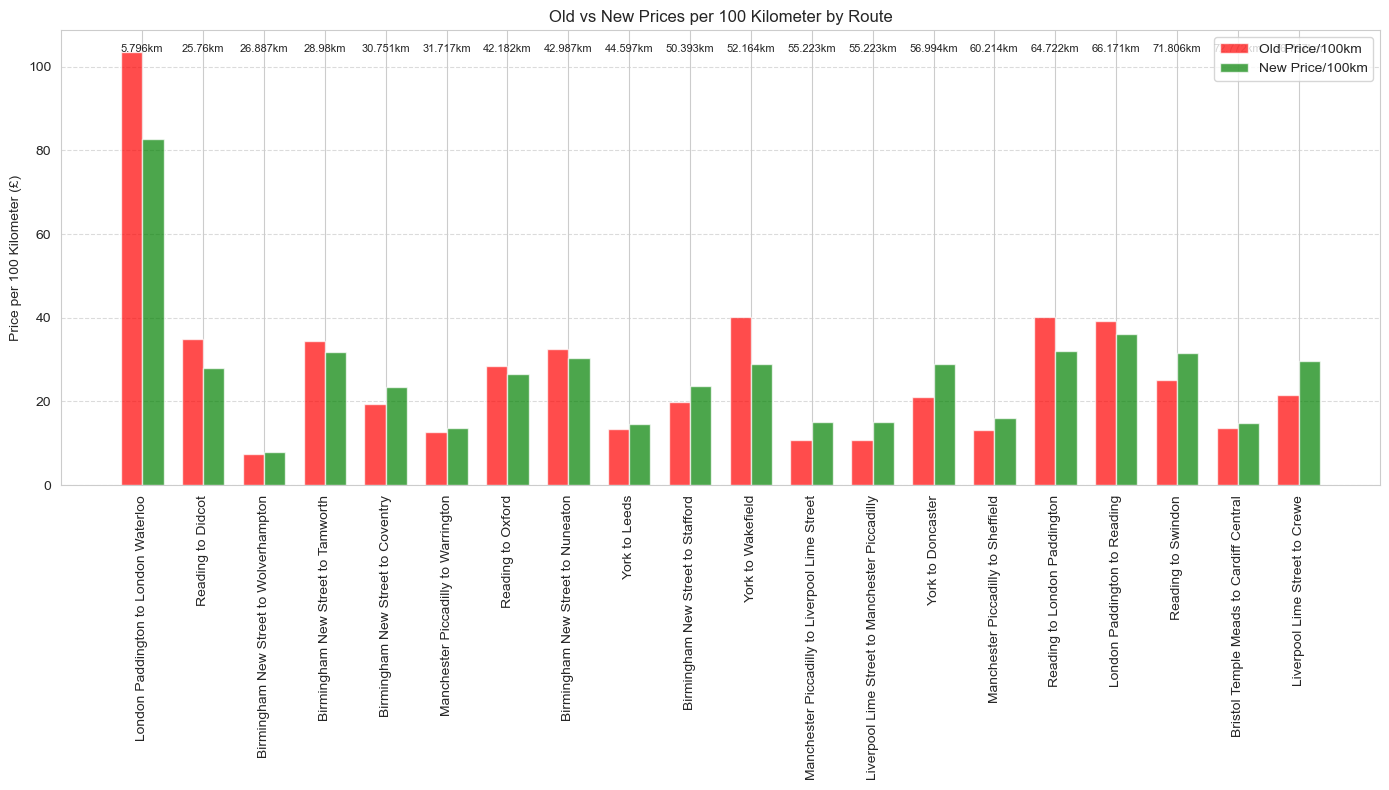

In [300]:
# Prepare data with route names and sort by distance
price_comparison = pricing_factors.reset_index()[['Route', 'Distance_y', 
                                                 'Target_Price_per_100km', 
                                                 'Final_Price']].copy()
price_comparison['New_Price_per_100km'] = price_comparison['Final_Price'] / price_comparison['Distance_y']
price_comparison = price_comparison.sort_values('Distance_y')

# Select top 20 routes for clarity (or use your preferred selection)
display_routes = price_comparison.head(20)

# Set up the visualization
plt.figure(figsize=(14, 8))
x = np.arange(len(display_routes))
bar_width = 0.35

# Plot old vs new prices
plt.bar(x - bar_width/2, display_routes['Target_Price_per_100km'], 
        width=bar_width, color='red', alpha=0.7, label='Old Price/100km')
plt.bar(x + bar_width/2, display_routes['New_Price_per_100km'], 
        width=bar_width, color='green', alpha=0.7, label='New Price/100km')

# Add labels and formatting
plt.xticks(x, display_routes['Route'], rotation=90)
plt.ylabel('Price per 100 Kilometer (£)')
plt.title('Old vs New Prices per 100 Kilometer by Route')
plt.legend()

# Add distance annotations
for i, dist in enumerate(display_routes['Distance_y']):
    plt.text(i, max(display_routes['Target_Price_per_100km'].max(), 
                   display_routes['New_Price_per_100km'].max()) + 0.02, 
             f'{dist}km', ha='center', fontsize=8)

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [276]:
df_merged.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station_x,...,CO2e emissionss_x,Expected_Price,Discount_Error,Departure Hour,Departure Station,Arrival Destination,mileage_y,Distance_y,CO2e emissionss_y,Price_per_100km
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,...,12.459677,43.215,0.215,11,London Paddington,Liverpool Lime Street,209.5,337.295,12.459677,38.245453
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,...,12.418046,23.115,0.115,9,London Kings Cross,York,208.8,336.168,12.418046,20.525452
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,No card,Standard,Advance,3,Liverpool Lime Street,...,2.039938,3.000,0.000,18,Liverpool Lime Street,Manchester Piccadilly,34.3,55.223,2.039938,10.865038
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,No card,Standard,Advance,13,London Paddington,...,2.444357,13.000,0.000,21,London Paddington,Reading,41.1,66.171,2.444357,39.292137
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,No card,Standard,Advance,76,Liverpool Lime Street,...,12.614308,76.000,0.000,16,Liverpool Lime Street,London Euston,212.1,341.481,12.614308,44.511993


In [1015]:
df_merged.to_csv('C:/DA/DEPI/Project/CSV/transactions4.csv', index=False)